# Prompt 5B - Fairness Audit and Final Explainability

The final Primary stayed frozen after IID. Prompt 5A reported Primary MAE 62.260626 and Global MAE 62.444349. Five of six frozen conditions passed; only the 3% Tail-improvement condition failed. No model was changed.

In [1]:
from pathlib import Path
import json
import pandas as pd
from IPython.display import display, Image
ROOT=Path('..')
R=ROOT/'outputs/reports'
F=ROOT/'outputs/figures/prompt5b'

## 1. Audit meaning and boundary

This is a predictive-error audit, not a causal or legal fair-lending test. Sensitive fields were never model inputs. They were joined after frozen prediction only. The original IID files stayed closed.

In [2]:
handoff=json.loads((R/'prompt5b_handoff_validation.json').read_text())
contract=json.loads((R/'prompt5b_sensitive_contract.json').read_text())
display(pd.DataFrame([{'handoff':handoff['status'],'aligned snapshots':sum(x['status']=='PASS' for x in handoff['checks']),'sensitive fields':contract['field_count'],'fits':0,'model changes':0}]))
display(pd.DataFrame(contract['fields']))

,handoff,aligned snapshots,sensitive fields,fits,model changes
0,PASS,15,8,0,0


,column_name,original_semantic_role,dtype,missing_count,unique_level_count,side,predictive_input
0,applicant_ethnicity_name,categorical ethnicity audit label,object,0,4,applicant,False
1,co_applicant_ethnicity_name,categorical ethnicity audit label,object,0,5,co-applicant,False
2,applicant_race_name_1,categorical first race audit label,object,0,7,applicant,False
3,co_applicant_race_name_1,categorical first race audit label,object,0,8,co-applicant,False
4,applicant_sex_name,categorical sex audit label,object,0,4,applicant,False
5,co_applicant_sex_name,categorical sex audit label,object,0,5,co-applicant,False
6,minority_population,continuous tract minority-population percentage,float64,0,9018,tract,False
7,majority_minority_tract,derived categorical tract audit label,object,0,2,tract,False


## 2. Group sizes and target composition

Group target distributions differ. Error gaps may reflect target composition, available covariates, model behavior, or combinations of these factors.

In [3]:
inv=pd.read_csv(R/'prompt5b_group_inventory.csv')
display(inv[inv.analysis_status.eq('ELIGIBLE')])
display(inv.groupby('sensitive_field').agg(levels=('group_label','size'),eligible=('analysis_status',lambda x:(x=='ELIGIBLE').sum()),small=('analysis_status',lambda x:(x=='SMALL_GROUP').sum())).reset_index())

,sensitive_field,group_label,n,iid_fraction,mean_target,median_target,d10_fraction,top5_target_fraction,missing_unknown_status,analysis_status,target_composition_warning
0,applicant_ethnicity_name,Hispanic or Latino,7760,0.103467,218.900000,192.0,0.062500,0.021778,OBSERVED,ELIGIBLE,Descriptive; group target distributions differ.
1,applicant_ethnicity_name,"Information not provided by applicant in mail,...",7574,0.100987,275.267890,217.0,0.130182,0.068788,UNKNOWN_OR_NOT_PROVIDED,ELIGIBLE,Descriptive; group target distributions differ.
2,applicant_ethnicity_name,Not Hispanic or Latino,59613,0.794840,250.232063,202.0,0.100733,0.051801,OBSERVED,ELIGIBLE,Descriptive; group target distributions differ.
4,co_applicant_ethnicity_name,Hispanic or Latino,3239,0.043187,250.523927,220.0,0.091386,0.036431,OBSERVED,ELIGIBLE,Descriptive; group target distributions differ.
5,co_applicant_ethnicity_name,"Information not provided by applicant in mail,...",3893,0.051907,301.196763,240.0,0.159774,0.082969,UNKNOWN_OR_NOT_PROVIDED,ELIGIBLE,Descriptive; group target distributions differ.
6,co_applicant_ethnicity_name,No co-applicant,40692,0.542560,222.414824,180.0,0.072742,0.036002,NO_CO_APPLICANT,ELIGIBLE,Descriptive; group target distributions differ.
7,co_applicant_ethnicity_name,Not Hispanic or Latino,27118,0.361573,282.799985,230.5,0.132679,0.069142,OBSERVED,ELIGIBLE,Descriptive; group target distributions differ.
9,applicant_race_name_1,American Indian or Alaska Native,507,0.006760,207.958580,179.0,0.076923,0.027613,OBSERVED,ELIGIBLE,Descriptive; group target distributions differ.
10,applicant_race_name_1,Asian,4792,0.063893,358.291319,300.0,0.246661,0.130843,OBSERVED,ELIGIBLE,Descriptive; group target distributions differ.
11,applicant_race_name_1,Black or African American,4800,0.064000,201.034375,176.0,0.046458,0.018958,OBSERVED,ELIGIBLE,Descriptive; group target distributions differ.


,sensitive_field,levels,eligible,small
0,applicant_ethnicity_name,4,3,1
1,applicant_race_name_1,7,6,1
2,applicant_sex_name,4,3,1
3,co_applicant_ethnicity_name,5,4,1
4,co_applicant_race_name_1,8,5,3
5,co_applicant_sex_name,5,4,1
6,majority_minority_tract,2,2,0
7,minority_population,9018,0,9018


## 3. Primary group error

,sensitive_field,group_label,n,iid_fraction,mean_target,median_target,d10_fraction,top5_target_fraction,missing_unknown_status,analysis_status,target_composition_warning,mae,rmse,mape_percent,wape_percent,mean_signed_error,median_signed_error,underprediction_rate,p90_absolute_error,mean_prediction
0,applicant_ethnicity_name,Hispanic or Latino,7760,0.103467,218.900000,192.0,0.062500,0.021778,OBSERVED,ELIGIBLE,Descriptive; group target distributions differ.,46.266520,75.299198,30.836867,21.135916,-2.582159,-0.533975,0.507732,102.270113,216.317841
1,applicant_ethnicity_name,"Information not provided by applicant in mail,...",7574,0.100987,275.267890,217.0,0.130182,0.068788,UNKNOWN_OR_NOT_PROVIDED,ELIGIBLE,Descriptive; group target distributions differ.,70.341005,139.416027,34.344996,25.553654,-8.867394,0.320481,0.497359,149.036496,266.400496
2,applicant_ethnicity_name,Not Hispanic or Latino,59613,0.794840,250.232063,202.0,0.100733,0.051801,OBSERVED,ELIGIBLE,Descriptive; group target distributions differ.,63.250586,139.679569,33.798050,25.276771,-8.699169,-0.925588,0.508513,135.149490,241.532894
4,co_applicant_ethnicity_name,Hispanic or Latino,3239,0.043187,250.523927,220.0,0.091386,0.036431,OBSERVED,ELIGIBLE,Descriptive; group target distributions differ.,54.188032,88.289635,31.709277,21.629883,-1.175644,1.838774,0.486261,118.795177,249.348283
5,co_applicant_ethnicity_name,"Information not provided by applicant in mail,...",3893,0.051907,301.196763,240.0,0.159774,0.082969,UNKNOWN_OR_NOT_PROVIDED,ELIGIBLE,Descriptive; group target distributions differ.,76.737767,147.471888,33.527471,25.477620,-7.094400,0.945007,0.494477,162.628796,294.102363
6,co_applicant_ethnicity_name,No co-applicant,40692,0.542560,222.414824,180.0,0.072742,0.036002,NO_CO_APPLICANT,ELIGIBLE,Descriptive; group target distributions differ.,54.182090,105.454465,33.100042,24.360827,-7.093164,-0.868049,0.509879,116.147544,215.321660
7,co_applicant_ethnicity_name,Not Hispanic or Latino,27118,0.361573,282.799985,230.5,0.132679,0.069142,OBSERVED,ELIGIBLE,Descriptive; group target distributions differ.,73.309092,172.034990,34.465246,25.922594,-10.603871,-0.989439,0.507596,153.984220,272.196114
9,applicant_race_name_1,American Indian or Alaska Native,507,0.006760,207.958580,179.0,0.076923,0.027613,OBSERVED,ELIGIBLE,Descriptive; group target distributions differ.,46.970604,69.382371,36.730809,22.586519,2.702385,4.145916,0.449704,107.521521,210.660965
10,applicant_race_name_1,Asian,4792,0.063893,358.291319,300.0,0.246661,0.130843,OBSERVED,ELIGIBLE,Descriptive; group target distributions differ.,83.288731,143.580137,28.281716,23.246093,-14.759529,-10.964252,0.559891,181.044045,343.531789
11,applicant_race_name_1,Black or African American,4800,0.064000,201.034375,176.0,0.046458,0.018958,OBSERVED,ELIGIBLE,Descriptive; group target distributions differ.,43.370690,76.972069,33.175844,21.573768,-5.014252,-0.993003,0.515208,94.853204,196.020123


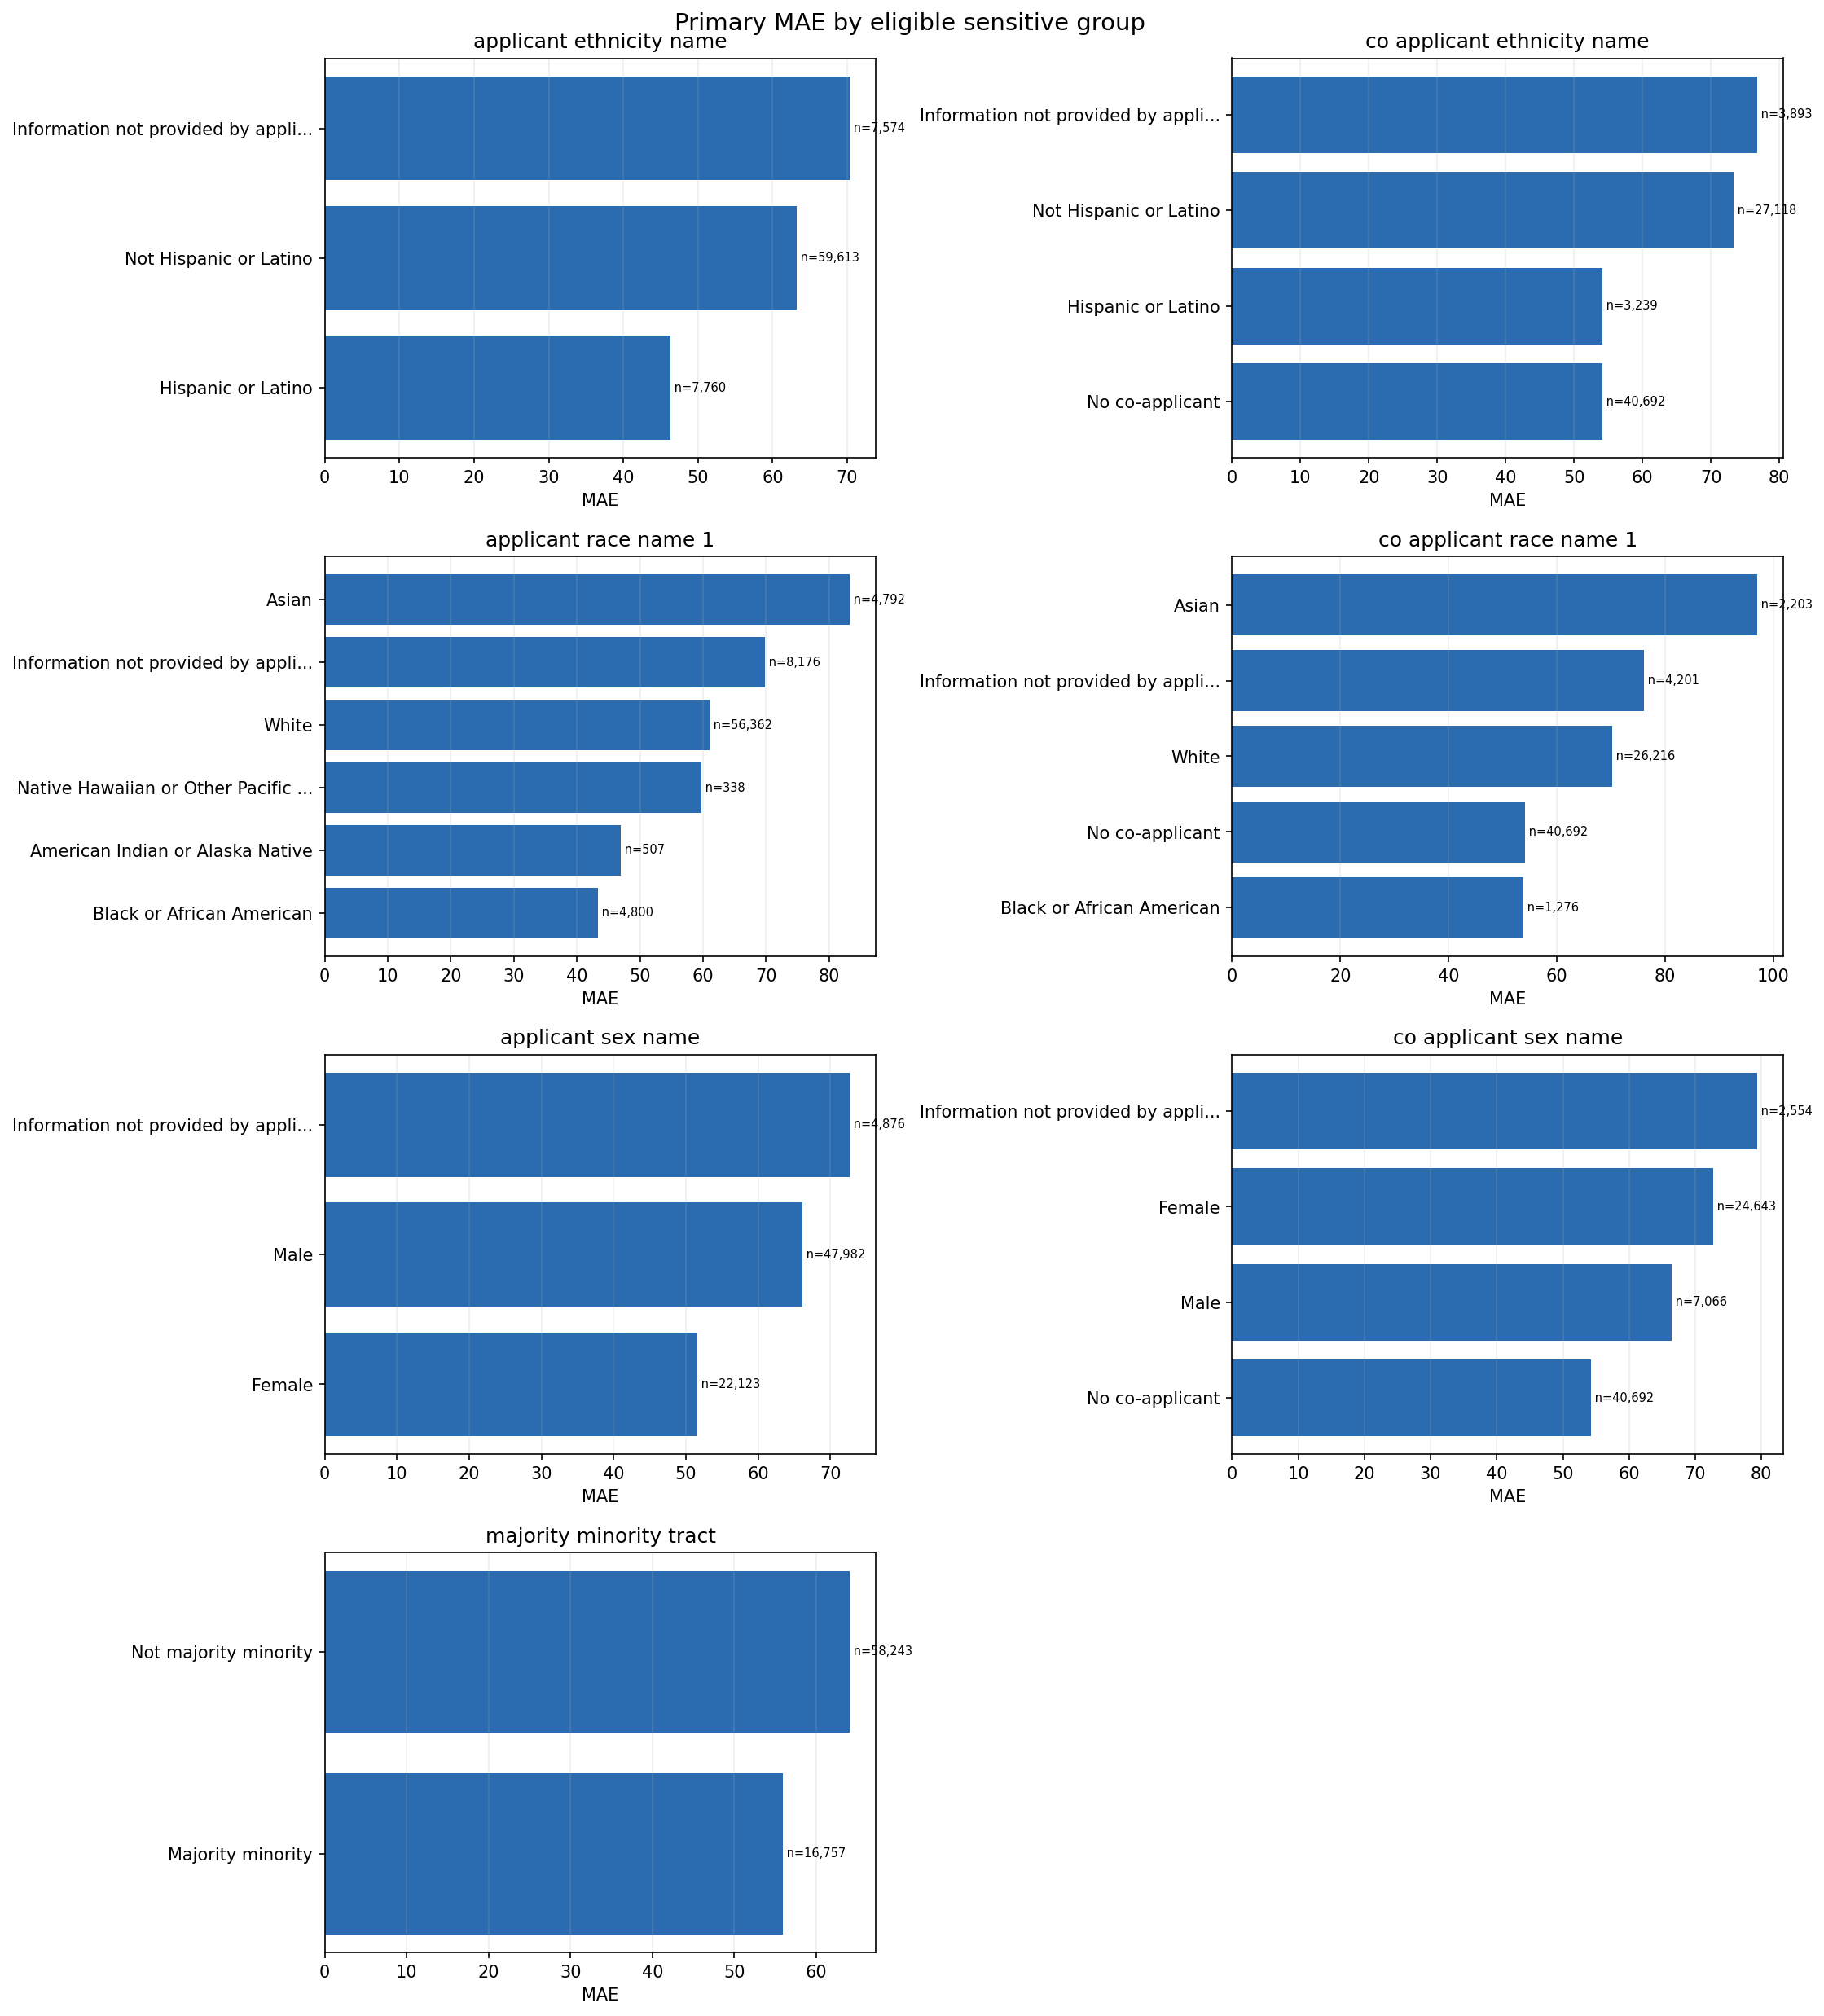

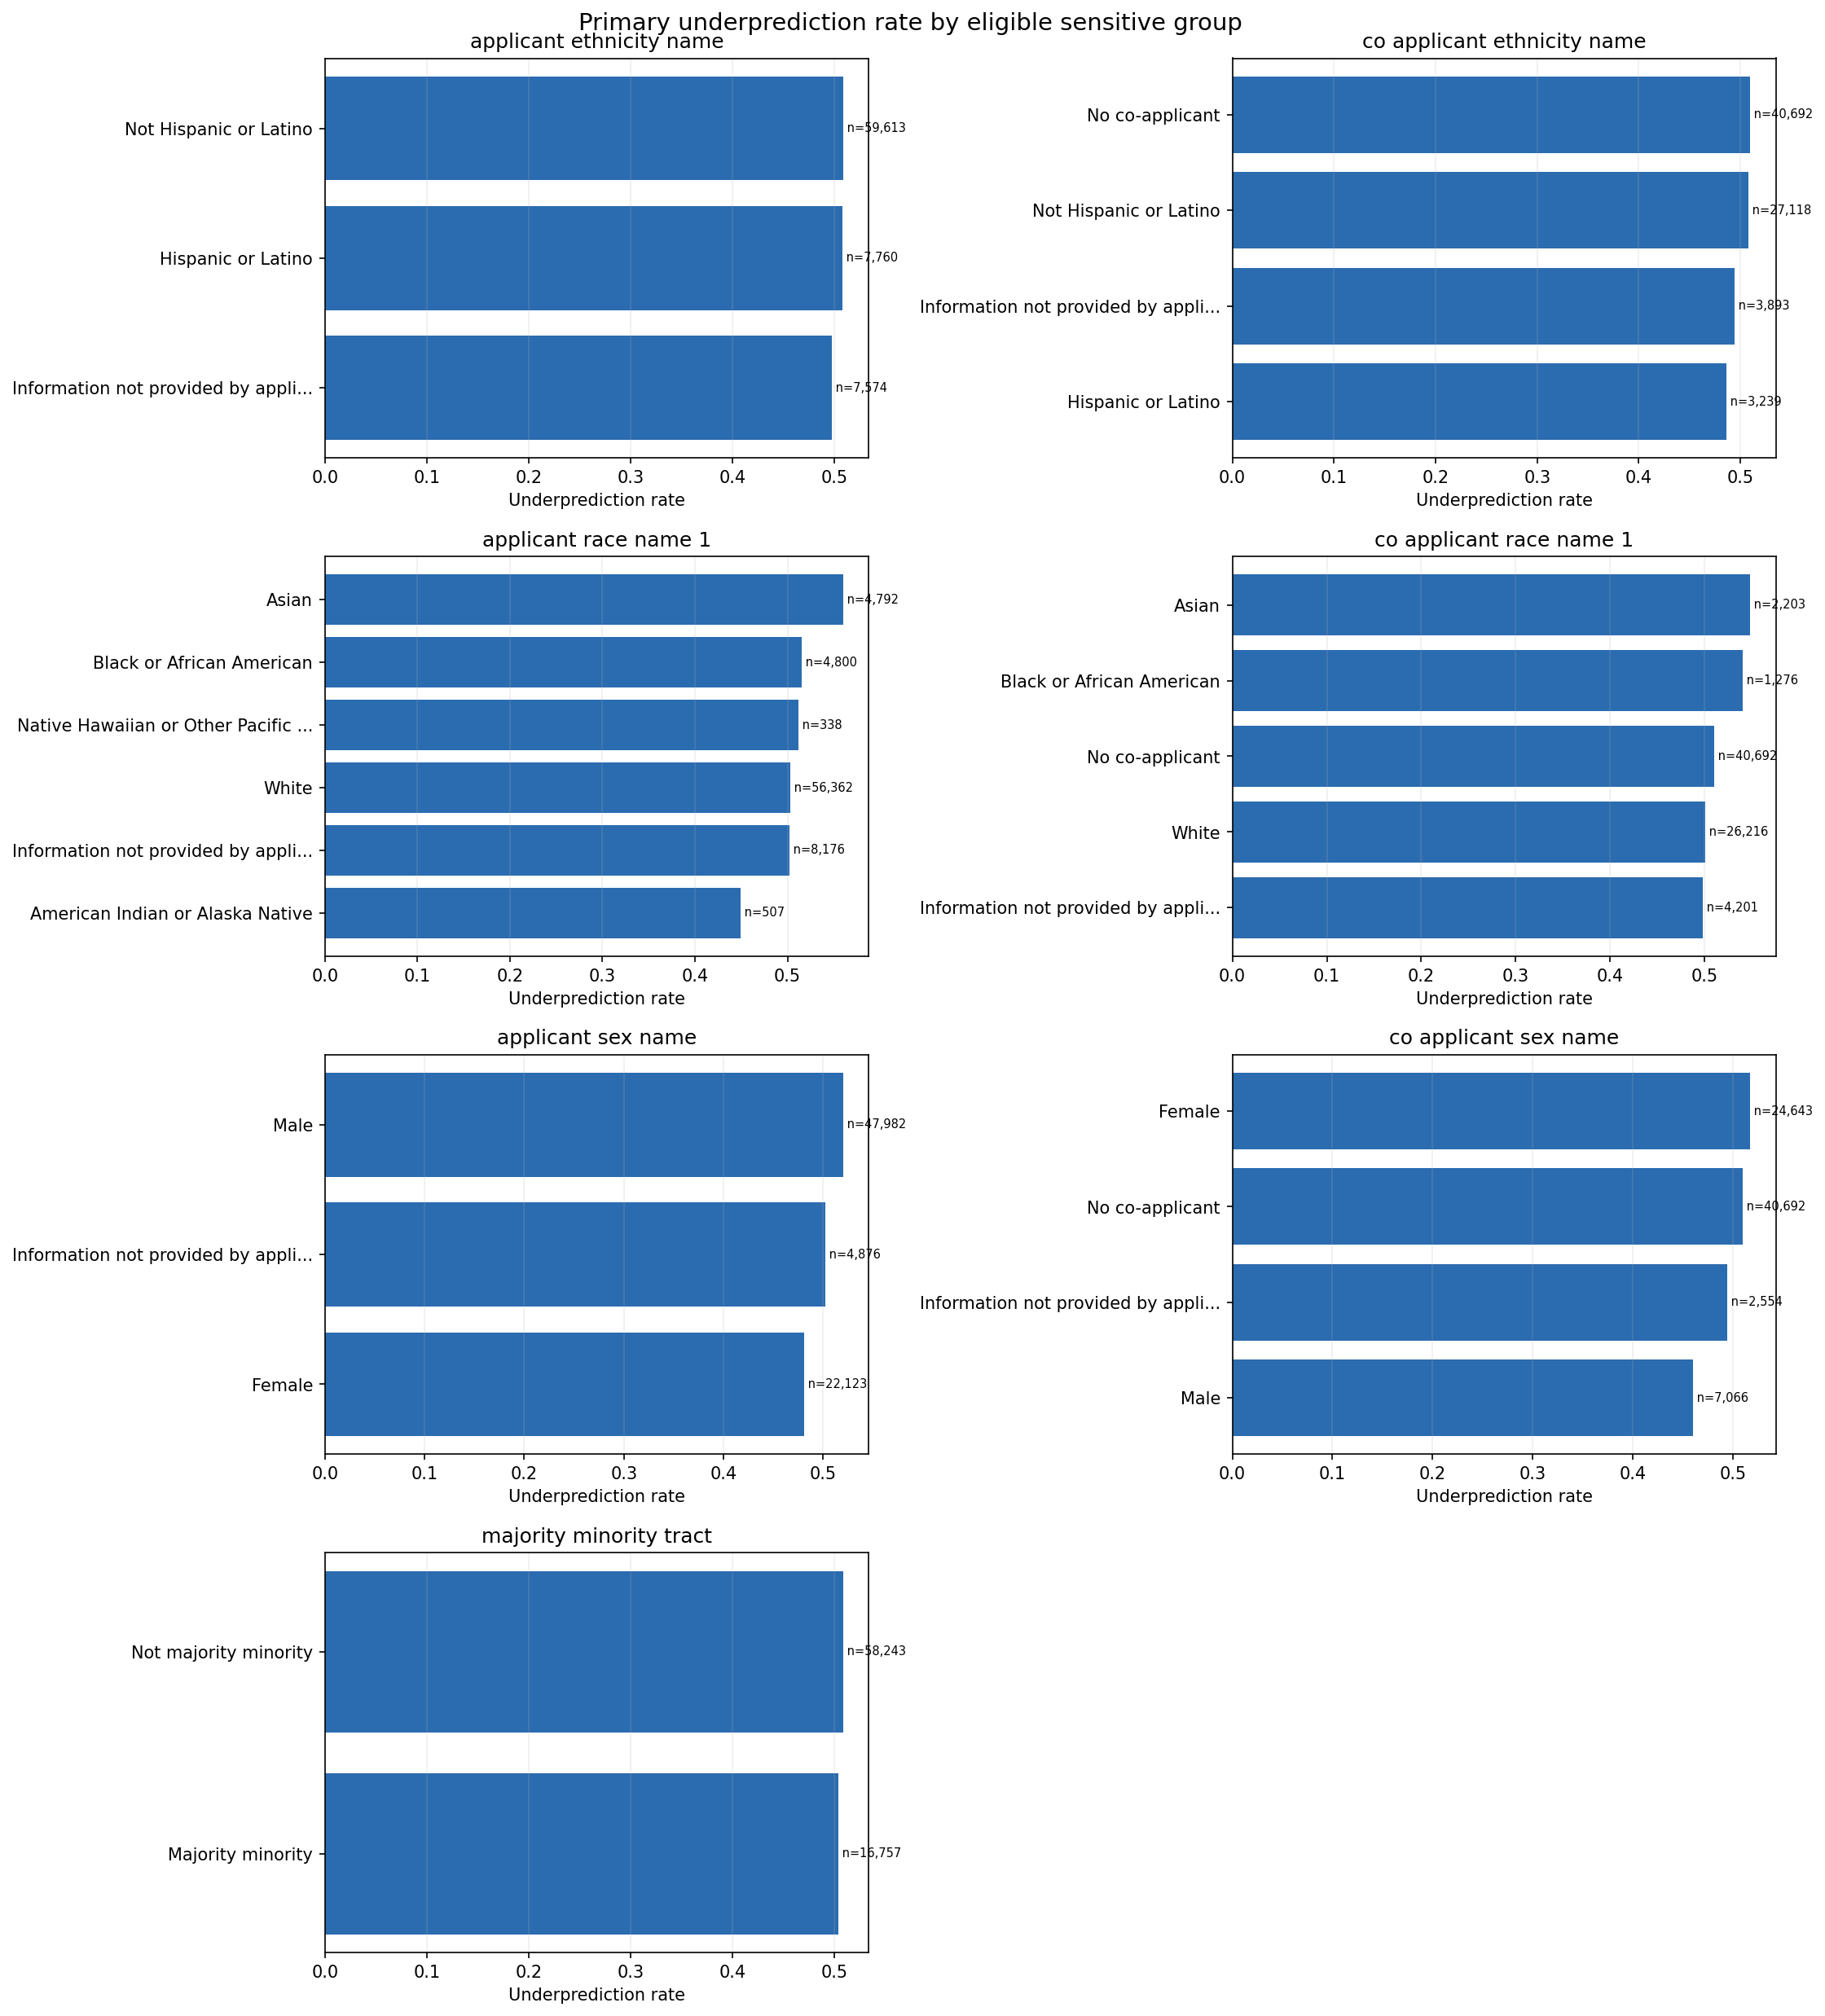

In [4]:
primary=pd.read_csv(R/'prompt5b_primary_group_metrics.csv')
display(primary[primary.analysis_status.eq('ELIGIBLE')])
display(Image(filename=str(F/'01_primary_mae_by_sensitive_group.png')))
display(Image(filename=str(F/'03_underprediction_by_sensitive_group.png')))

## 4. Primary versus Global within groups

Negative MAE difference means the Tail-aware Primary performed better than Global in that group.

,sensitive_field,group_label,n,iid_fraction,mean_target,median_target,d10_fraction,top5_target_fraction,missing_unknown_status,analysis_status,target_composition_warning,primary_minus_global_mae,primary_minus_global_rmse,primary_minus_global_mape_percent,primary_minus_global_wape_percent,primary_minus_global_signed_error_distance_to_zero,primary_minus_global_underprediction_rate,primary_row_win_rate
0,applicant_ethnicity_name,Hispanic or Latino,7760,0.103467,218.900000,192.0,0.062500,0.021778,OBSERVED,ELIGIBLE,Descriptive; group target distributions differ.,-0.087462,-0.459862,0.003681,-0.039955,-0.405948,-0.000515,0.013402
1,applicant_ethnicity_name,"Information not provided by applicant in mail,...",7574,0.100987,275.267890,217.0,0.130182,0.068788,UNKNOWN_OR_NOT_PROVIDED,ELIGIBLE,Descriptive; group target distributions differ.,-0.706760,-5.772851,0.023472,-0.256753,-2.332958,-0.002509,0.038157
2,applicant_ethnicity_name,Not Hispanic or Latino,59613,0.794840,250.232063,202.0,0.100733,0.051801,OBSERVED,ELIGIBLE,Descriptive; group target distributions differ.,-0.130562,-2.204183,0.034179,-0.052176,-1.314806,-0.001677,0.025900
4,co_applicant_ethnicity_name,Hispanic or Latino,3239,0.043187,250.523927,220.0,0.091386,0.036431,OBSERVED,ELIGIBLE,Descriptive; group target distributions differ.,-0.136767,-0.485628,0.011026,-0.054592,-0.624036,0.000000,0.020994
5,co_applicant_ethnicity_name,"Information not provided by applicant in mail,...",3893,0.051907,301.196763,240.0,0.159774,0.082969,UNKNOWN_OR_NOT_PROVIDED,ELIGIBLE,Descriptive; group target distributions differ.,-0.682305,-5.431821,0.030874,-0.226531,-2.786980,-0.002055,0.048549
6,co_applicant_ethnicity_name,No co-applicant,40692,0.542560,222.414824,180.0,0.072742,0.036002,NO_CO_APPLICANT,ELIGIBLE,Descriptive; group target distributions differ.,-0.120723,-2.014365,0.018804,-0.054279,-0.996367,-0.001499,0.017841
7,co_applicant_ethnicity_name,Not Hispanic or Latino,27118,0.361573,282.799985,230.5,0.132679,0.069142,OBSERVED,ELIGIBLE,Descriptive; group target distributions differ.,-0.211803,-2.817564,0.049834,-0.074895,-1.699013,-0.001991,0.035216
9,applicant_race_name_1,American Indian or Alaska Native,507,0.006760,207.958580,179.0,0.076923,0.027613,OBSERVED,ELIGIBLE,Descriptive; group target distributions differ.,-0.233481,0.011230,-0.028320,-0.112273,0.467284,-0.001972,0.017751
10,applicant_race_name_1,Asian,4792,0.063893,358.291319,300.0,0.246661,0.130843,OBSERVED,ELIGIBLE,Descriptive; group target distributions differ.,-0.350731,-3.865485,0.049255,-0.097890,-2.942411,-0.004382,0.074917
11,applicant_race_name_1,Black or African American,4800,0.064000,201.034375,176.0,0.046458,0.018958,OBSERVED,ELIGIBLE,Descriptive; group target distributions differ.,-0.107205,-2.303145,0.001540,-0.053327,-0.384157,-0.000833,0.010833


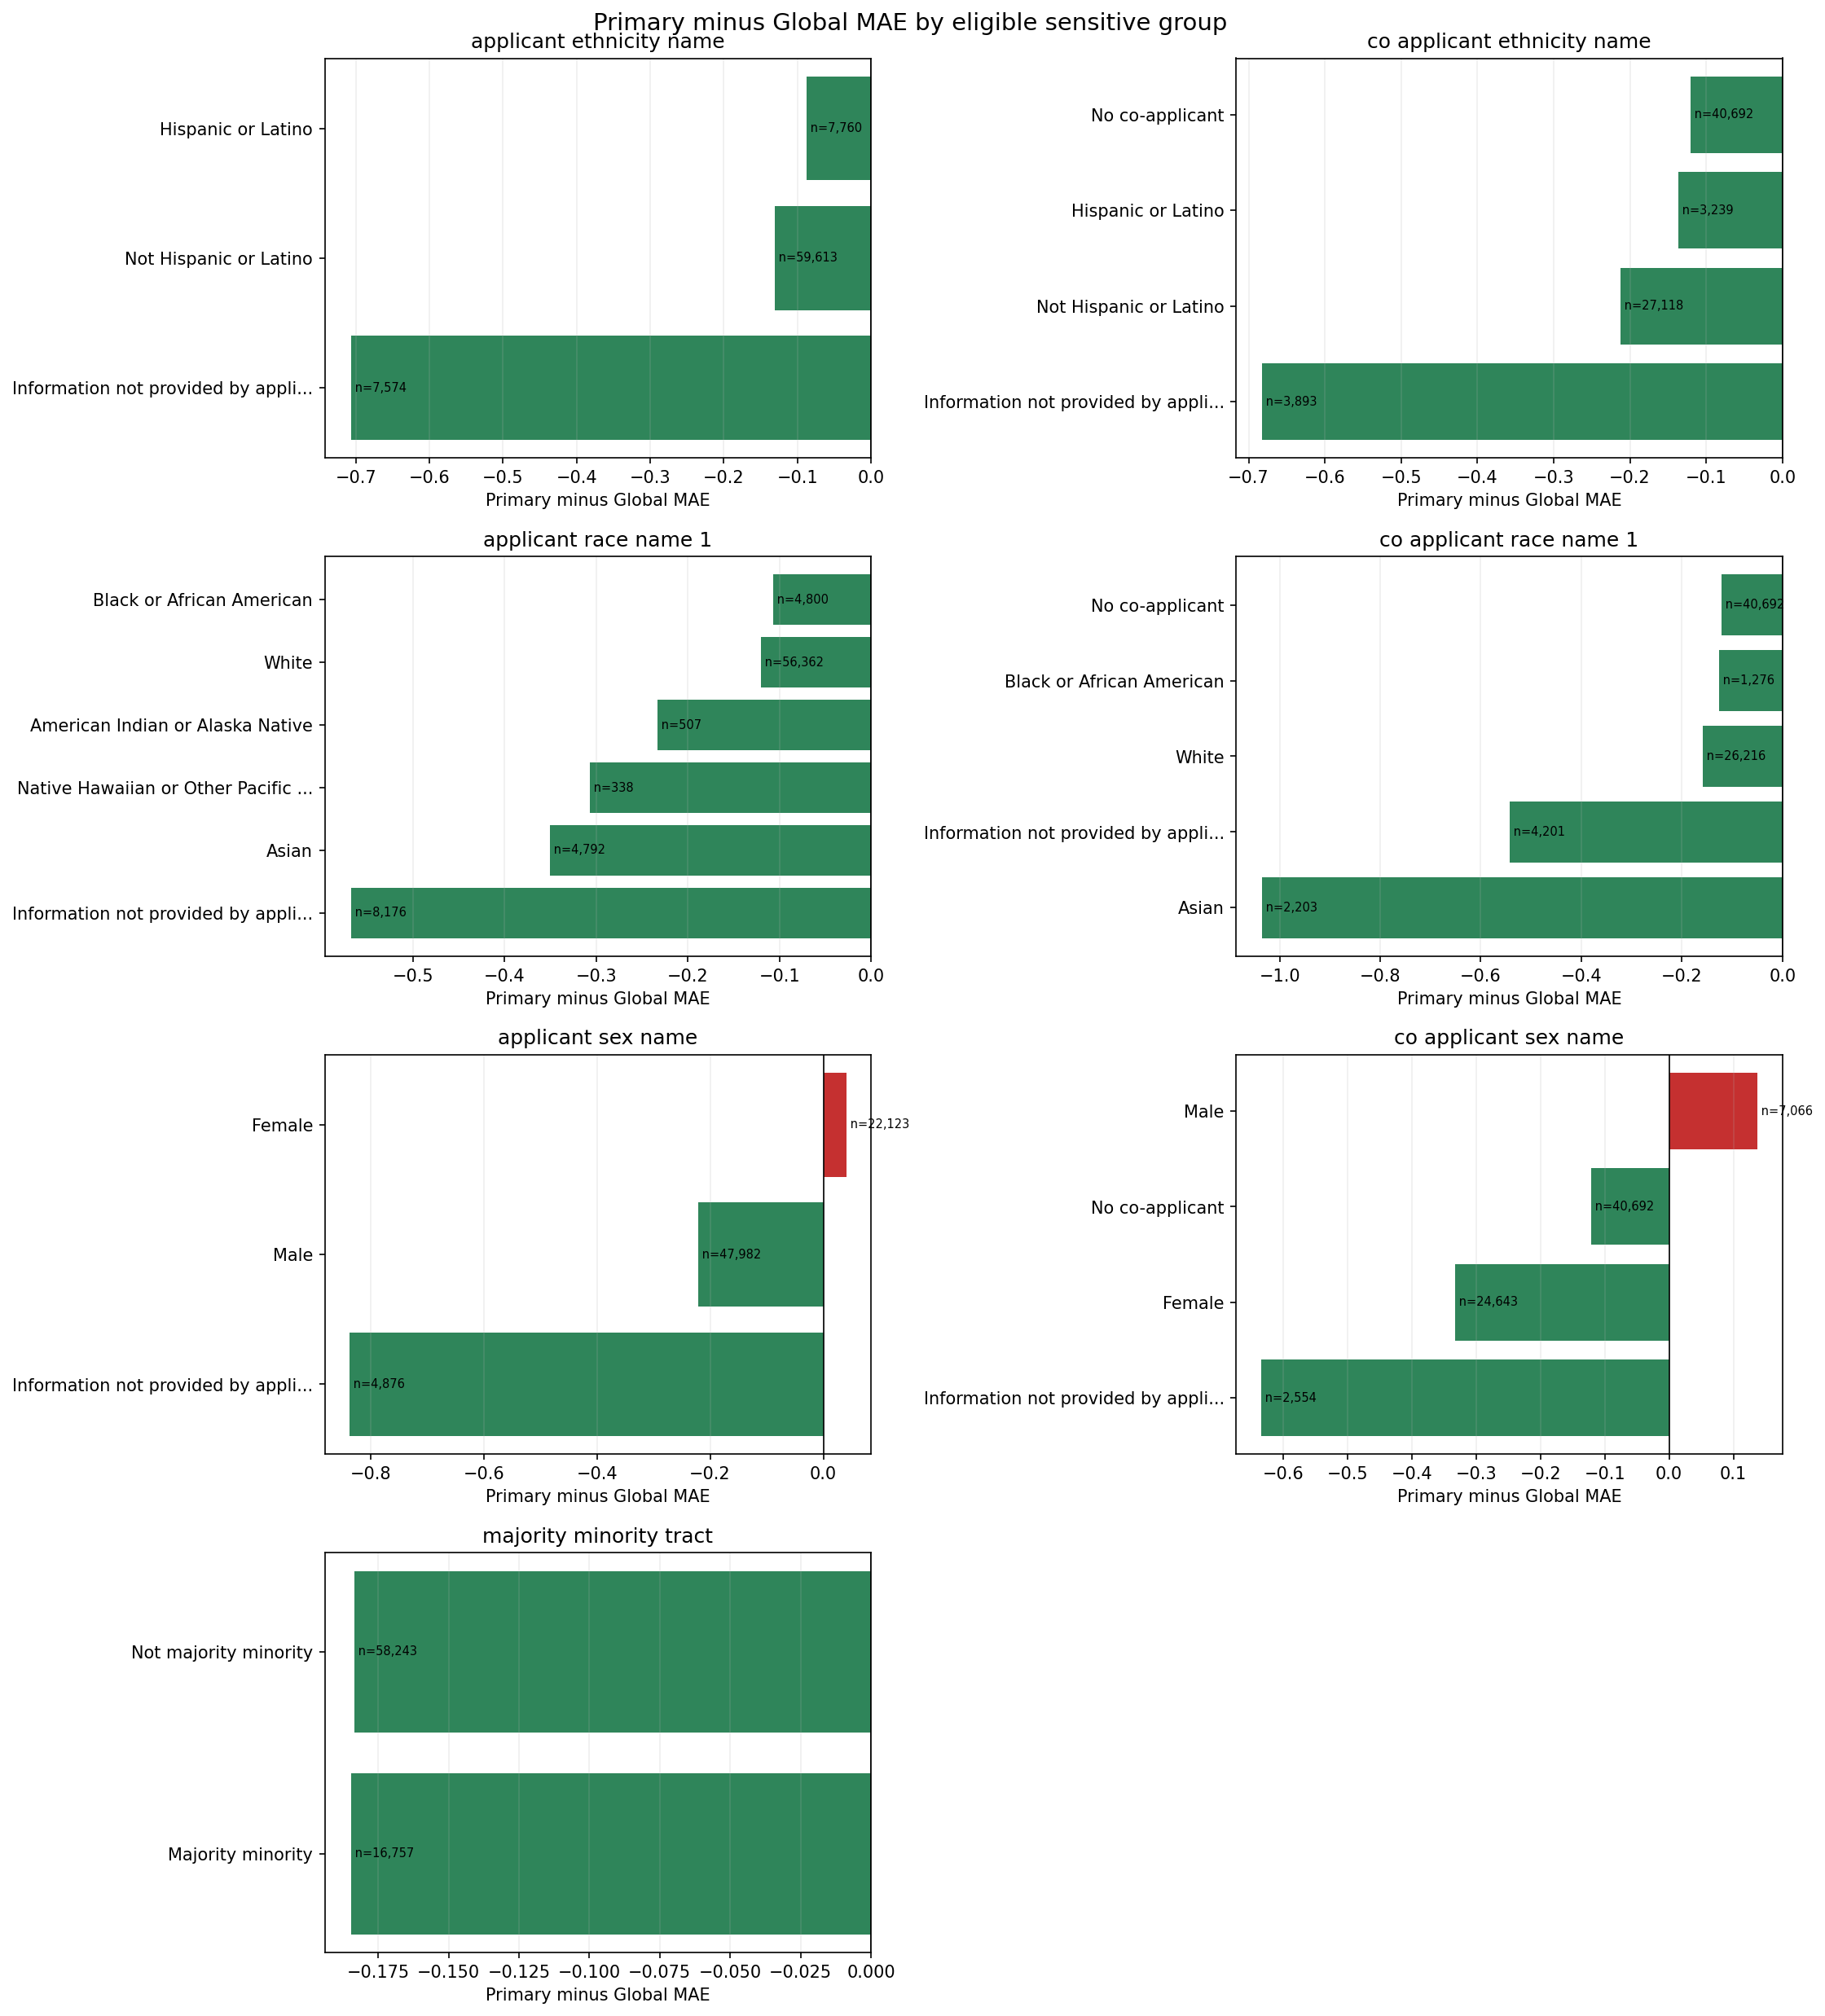

In [5]:
compare=pd.read_csv(R/'prompt5b_group_primary_vs_global.csv')
display(compare[compare.analysis_status.eq('ELIGIBLE')])
display(Image(filename=str(F/'02_primary_minus_global_by_sensitive_group.png')))

## 5. Descriptive disparity summary and uncertainty

Ratios and gaps below are descriptive. They are not legal fairness violations or pass/fail tests.

,sensitive_field,eligible_group_count,min_mae_group,min_group_mae,max_mae_group,max_group_mae,mae_max_minus_min,mae_max_min_ratio,max_group_mae_minus_overall,min_wape_group,...,most_positive_signed_group,most_positive_signed_error,signed_error_range,max_distance_from_zero,min_underprediction_group,min_underprediction_rate,max_underprediction_group,max_underprediction_rate,underprediction_gap_percentage_points,interpretation
0,applicant_ethnicity_name,3,Hispanic or Latino,46.266520,"Information not provided by applicant in mail,...",70.341005,24.074484,1.520344,8.080379,Hispanic or Latino,...,Hispanic or Latino,-2.582159,6.285235,8.867394,"Information not provided by applicant in mail,...",0.497359,Not Hispanic or Latino,0.508513,1.115386,Descriptive predictive-error disparity; not a ...
1,co_applicant_ethnicity_name,4,No co-applicant,54.182090,"Information not provided by applicant in mail,...",76.737767,22.555677,1.416294,14.477141,Hispanic or Latino,...,Hispanic or Latino,-1.175644,9.428227,10.603871,Hispanic or Latino,0.486261,No co-applicant,0.509879,2.361790,Descriptive predictive-error disparity; not a ...
2,applicant_race_name_1,6,Black or African American,43.370690,Asian,83.288731,39.918041,1.920392,21.028105,Native Hawaiian or Other Pacific Islander,...,American Indian or Alaska Native,2.702385,17.461915,14.759529,American Indian or Alaska Native,0.449704,Asian,0.559891,11.018734,Descriptive predictive-error disparity; not a ...
3,co_applicant_race_name_1,5,Black or African American,53.761946,Asian,97.016910,43.254964,1.804565,34.756284,Black or African American,...,"Information not provided by applicant in mail,...",-7.078059,12.229520,19.307579,"Information not provided by applicant in mail,...",0.498215,Asian,0.548343,5.012846,Descriptive predictive-error disparity; not a ...
4,applicant_sex_name,3,Female,51.525145,"Information not provided by applicant in mail,...",72.676293,21.151149,1.410501,10.415667,Female,...,Female,0.732370,12.709984,11.977614,Female,0.481219,Male,0.519820,3.860129,Descriptive predictive-error disparity; not a ...
5,co_applicant_sex_name,4,No co-applicant,54.182090,"Information not provided by applicant in mail,...",79.341465,25.159375,1.464349,17.080839,No co-applicant,...,Male,4.794403,18.201557,13.407154,Male,0.460091,Female,0.517713,5.762237,Descriptive predictive-error disparity; not a ...
6,majority_minority_tract,2,Majority minority,55.888121,Not majority minority,64.094049,8.205928,1.146828,1.833423,Majority minority,...,Majority minority,-4.845041,4.202506,9.047546,Majority minority,0.503610,Not majority minority,0.508353,0.474250,Descriptive predictive-error disparity; not a ...


,sensitive_field,group_label,n,mean_target,median_target,d10_fraction,top5_target_fraction,mae,underprediction_rate,elevated_mae_descriptive,elevated_underprediction_descriptive,descriptive_flags,legal_fairness_determination
0,applicant_ethnicity_name,Hispanic or Latino,7760,218.900000,192.0,0.062500,0.021778,46.266520,0.507732,False,False,NONE,False
1,applicant_ethnicity_name,"Information not provided by applicant in mail,...",7574,275.267890,217.0,0.130182,0.068788,70.341005,0.497359,True,False,ELEVATED_MAE_DESCRIPTIVE,False
2,applicant_ethnicity_name,Not Hispanic or Latino,59613,250.232063,202.0,0.100733,0.051801,63.250586,0.508513,True,False,ELEVATED_MAE_DESCRIPTIVE,False
3,co_applicant_ethnicity_name,Hispanic or Latino,3239,250.523927,220.0,0.091386,0.036431,54.188032,0.486261,False,False,NONE,False
4,co_applicant_ethnicity_name,"Information not provided by applicant in mail,...",3893,301.196763,240.0,0.159774,0.082969,76.737767,0.494477,True,False,ELEVATED_MAE_DESCRIPTIVE,False
5,co_applicant_ethnicity_name,No co-applicant,40692,222.414824,180.0,0.072742,0.036002,54.182090,0.509879,False,False,NONE,False
6,co_applicant_ethnicity_name,Not Hispanic or Latino,27118,282.799985,230.5,0.132679,0.069142,73.309092,0.507596,True,False,ELEVATED_MAE_DESCRIPTIVE,False
7,applicant_race_name_1,American Indian or Alaska Native,507,207.958580,179.0,0.076923,0.027613,46.970604,0.449704,False,False,NONE,False
8,applicant_race_name_1,Asian,4792,358.291319,300.0,0.246661,0.130843,83.288731,0.559891,True,True,ELEVATED_MAE_DESCRIPTIVE;ELEVATED_UNDERPREDICT...,False
9,applicant_race_name_1,Black or African American,4800,201.034375,176.0,0.046458,0.018958,43.370690,0.515208,False,False,NONE,False


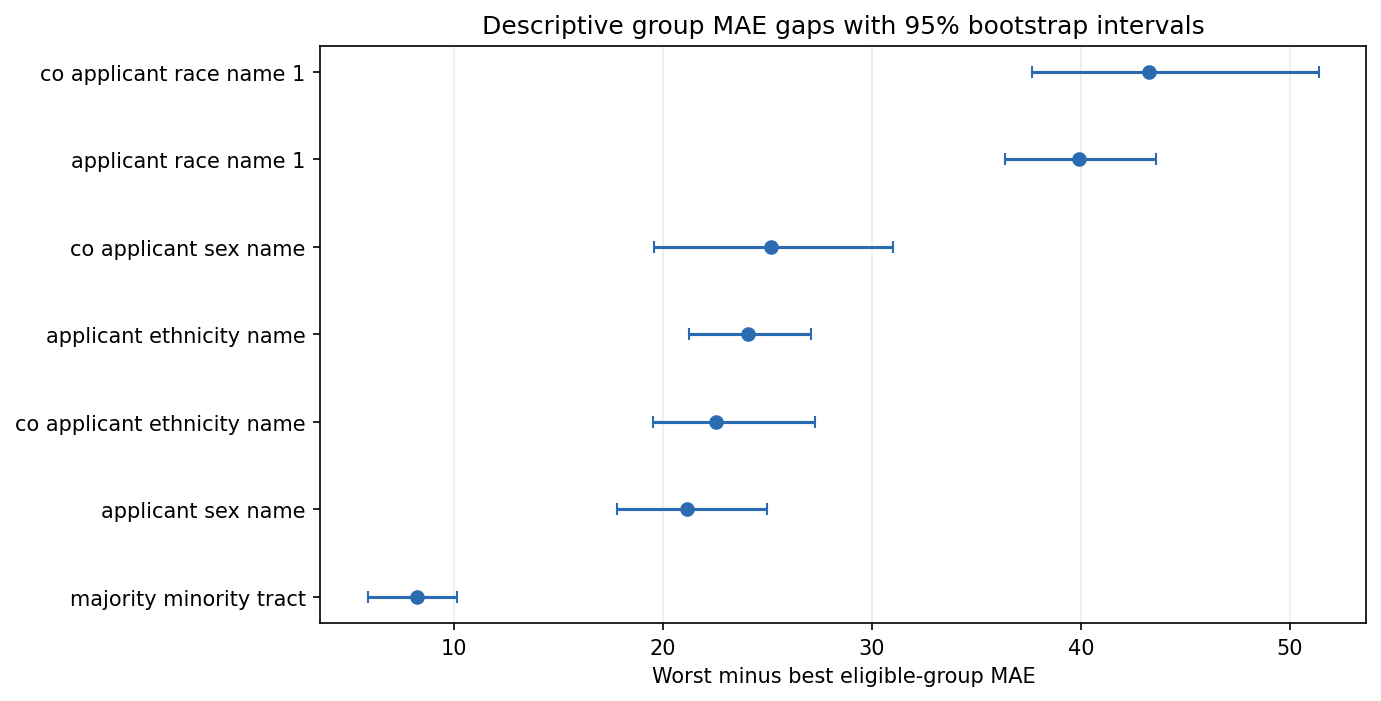

In [6]:
display(pd.read_csv(R/'prompt5b_disparity_summary.csv'))
display(pd.read_csv(R/'prompt5b_fairness_flags.csv'))
display(Image(filename=str(F/'05_group_mae_gaps_bootstrap.png')))

## 6. Common IID Tail groups

Every group uses the same IID-global D10 and top-5% target masks. No group-specific Tail threshold was used.

,sensitive_field,group_label,tail_scope,n,mean_target,median_target,d10_fraction,top5_target_fraction,analysis_status,target_composition_warning,primary_tail_mae,global_tail_mae,primary_signed_error,global_signed_error,primary_underprediction_rate,global_underprediction_rate,primary_minus_global_tail_mae
0,applicant_ethnicity_name,Hispanic or Latino,IID_GLOBAL_TOP_DECILE,487,601.273101,540.0,0.995893,0.347023,ELIGIBLE,Common IID-global Tail mask; descriptive only.,138.268471,140.036960,-100.899871,-106.993509,0.819302,0.827515,-1.768490
1,applicant_ethnicity_name,"Information not provided by applicant in mail,...",IID_GLOBAL_TOP_DECILE,986,757.593306,600.0,1.000000,0.528398,ELIGIBLE,Common IID-global Tail mask; descriptive only.,198.827051,205.168814,-133.028531,-150.036486,0.778905,0.798174,-6.341763
2,applicant_ethnicity_name,Not Hispanic or Latino,IID_GLOBAL_TOP_DECILE,6025,717.975934,595.0,0.996680,0.512531,ELIGIBLE,Common IID-global Tail mask; descriptive only.,194.620309,196.823182,-131.365372,-143.461735,0.771950,0.788548,-2.202873
4,applicant_ethnicity_name,Hispanic or Latino,IID_TOP5_TARGET,169,789.745562,675.0,1.000000,1.000000,ELIGIBLE,Common IID-global Tail mask; descriptive only.,215.285913,222.365302,-177.773105,-191.292713,0.893491,0.905325,-7.079389
5,applicant_ethnicity_name,"Information not provided by applicant in mail,...",IID_TOP5_TARGET,521,979.452975,768.0,1.000000,1.000000,ELIGIBLE,Common IID-global Tail mask; descriptive only.,277.402520,291.604710,-212.211750,-241.753001,0.809981,0.842610,-14.202191
6,applicant_ethnicity_name,Not Hispanic or Latino,IID_TOP5_TARGET,3088,919.342293,744.0,1.000000,1.000000,ELIGIBLE,Common IID-global Tail mask; descriptive only.,274.468268,280.936903,-203.406752,-224.339311,0.795661,0.820272,-6.468634
8,co_applicant_ethnicity_name,Hispanic or Latino,IID_GLOBAL_TOP_DECILE,296,622.168919,553.5,1.000000,0.398649,ELIGIBLE,Common IID-global Tail mask; descriptive only.,138.651199,140.958608,-102.300094,-108.317819,0.797297,0.797297,-2.307409
9,co_applicant_ethnicity_name,"Information not provided by applicant in mail,...",IID_GLOBAL_TOP_DECILE,622,747.360129,599.0,1.000000,0.519293,ELIGIBLE,Common IID-global Tail mask; descriptive only.,186.704382,191.768580,-112.809884,-129.459393,0.765273,0.778135,-5.064198
10,co_applicant_ethnicity_name,No co-applicant,IID_GLOBAL_TOP_DECILE,2971,709.863346,588.0,0.996298,0.493100,ELIGIBLE,Common IID-global Tail mask; descriptive only.,191.710733,194.137495,-135.452387,-148.322439,0.791989,0.812521,-2.426763
11,co_applicant_ethnicity_name,Not Hispanic or Latino,IID_GLOBAL_TOP_DECILE,3609,723.726794,599.0,0.996952,0.519534,ELIGIBLE,Common IID-global Tail mask; descriptive only.,197.581654,200.162326,-130.731037,-142.508222,0.762538,0.777501,-2.580672


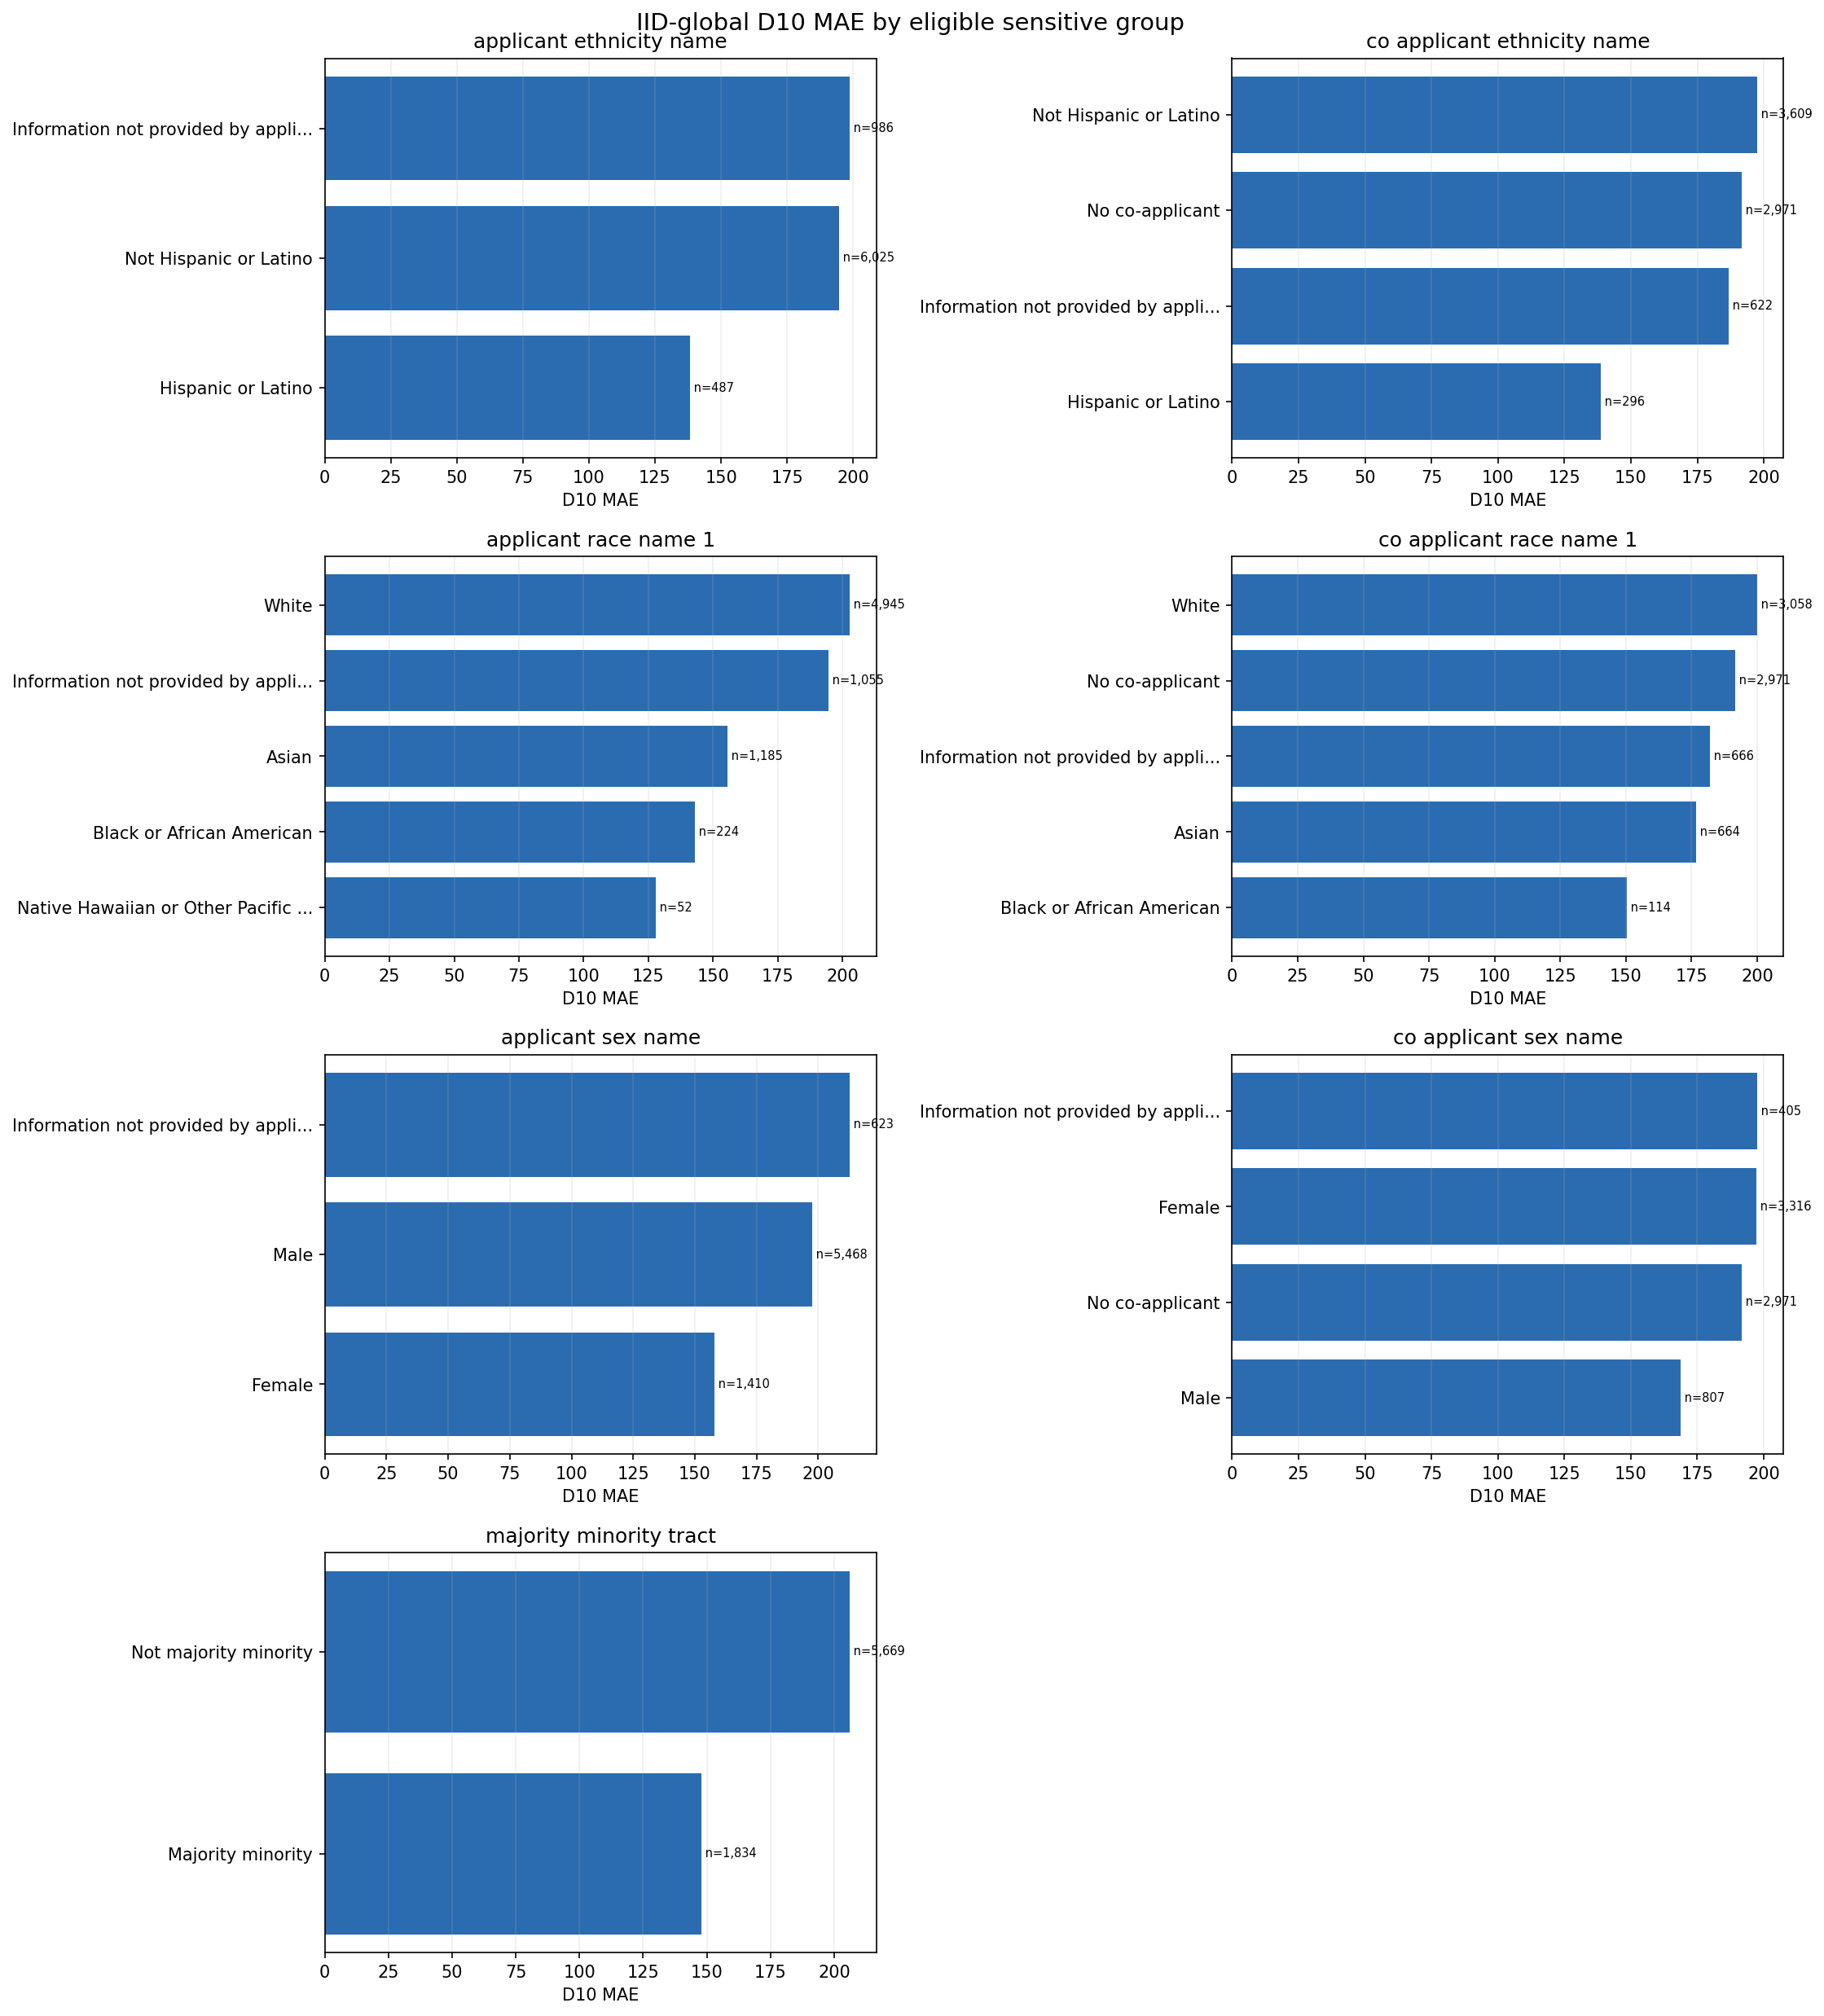

In [7]:
tail=pd.read_csv(R/'prompt5b_tail_group_metrics.csv')
display(tail[tail.analysis_status.eq('ELIGIBLE')])
display(Image(filename=str(F/'04_top_decile_mae_by_sensitive_group.png')))

## 7. Target-decile profiles

In [8]:
dec=pd.read_csv(R/'prompt5b_group_decile_metrics.csv')
display(dec[dec.cell_status.eq('DISPLAY')])

,sensitive_field,group_label,iid_target_decile,n,primary_mae,mean_target,median_target,cell_status,target_composition_warning
0,applicant_ethnicity_name,Hispanic or Latino,D1,788,25.002387,33.345178,32.0,DISPLAY,Target-decile cell; descriptive only.
1,applicant_ethnicity_name,Hispanic or Latino,D2,775,37.864184,92.478710,94.0,DISPLAY,Target-decile cell; descriptive only.
2,applicant_ethnicity_name,Hispanic or Latino,D3,840,32.438766,127.227381,127.0,DISPLAY,Target-decile cell; descriptive only.
3,applicant_ethnicity_name,Hispanic or Latino,D4,871,33.521105,157.094145,157.0,DISPLAY,Target-decile cell; descriptive only.
4,applicant_ethnicity_name,Hispanic or Latino,D5,898,35.868692,186.329621,186.0,DISPLAY,Target-decile cell; descriptive only.
...,...,...,...,...,...,...,...,...,...
265,majority_minority_tract,Not majority minority,D6,5894,44.491897,220.586529,220.0,DISPLAY,Target-decile cell; descriptive only.
266,majority_minority_tract,Not majority minority,D7,5813,53.068481,260.025804,260.0,DISPLAY,Target-decile cell; descriptive only.
267,majority_minority_tract,Not majority minority,D8,5875,63.963892,312.144170,310.0,DISPLAY,Target-decile cell; descriptive only.
268,majority_minority_tract,Not majority minority,D9,5742,84.892251,392.165622,394.0,DISPLAY,Target-decile cell; descriptive only.


## 8. Bounded applicant intersections

Only applicant race by applicant sex and applicant ethnicity by applicant sex were predeclared.

,intersection,scope,group_label,n,analysis_status,mean_target,median_target,d10_fraction,top5_target_fraction,mae,mape_percent,wape_percent,mean_signed_error,underprediction_rate,primary_minus_global_mae,target_composition_warning
9,applicant_race_x_applicant_sex,OVERALL,Asian | Female,1440,ELIGIBLE,310.766667,265.0,0.185417,0.084722,72.873798,29.558337,23.449683,-4.495675,0.538194,0.204813,Predeclared applicant-side intersection; descr...
10,applicant_race_x_applicant_sex,IID_GLOBAL_TOP_DECILE,Asian | Female,269,ELIGIBLE,645.754647,572.0,0.992565,0.453532,135.236875,19.945986,20.942455,-65.448925,0.698885,0.522168,Predeclared applicant-side intersection; descr...
11,applicant_race_x_applicant_sex,IID_TOP5_TARGET,Asian | Female,122,ELIGIBLE,820.836066,711.5,1.000000,1.000000,193.325513,23.049093,23.552268,-96.430933,0.704918,-1.634235,Predeclared applicant-side intersection; descr...
15,applicant_race_x_applicant_sex,OVERALL,Asian | Male,3334,ELIGIBLE,378.983203,316.0,0.273245,0.150870,87.916955,27.324189,23.198114,-19.235110,0.569586,-0.606071,Predeclared applicant-side intersection; descr...
16,applicant_race_x_applicant_sex,IID_GLOBAL_TOP_DECILE,Asian | Male,912,ELIGIBLE,712.871711,608.5,0.998904,0.551535,161.806752,21.168913,22.697878,-92.412002,0.730263,-2.819141,Predeclared applicant-side intersection; descr...
17,applicant_race_x_applicant_sex,IID_TOP5_TARGET,Asian | Male,503,ELIGIBLE,877.942346,745.0,1.000000,1.000000,209.727047,21.993583,23.888476,-138.546667,0.761431,-6.750782,Predeclared applicant-side intersection; descr...
21,applicant_race_x_applicant_sex,OVERALL,Black or African American | Female,2110,ELIGIBLE,183.778673,164.0,0.032227,0.009005,38.746901,35.787086,21.083459,-2.387214,0.504739,-0.064602,Predeclared applicant-side intersection; descr...
22,applicant_race_x_applicant_sex,IID_GLOBAL_TOP_DECILE,Black or African American | Female,68,ELIGIBLE,566.235294,542.0,1.000000,0.279412,113.605167,19.702077,20.063244,-98.448927,0.852941,-2.214978,Predeclared applicant-side intersection; descr...
27,applicant_race_x_applicant_sex,OVERALL,Black or African American | Male,2675,ELIGIBLE,214.731215,186.0,0.057944,0.026916,46.938181,31.111930,21.859040,-7.333317,0.524860,-0.141411,Predeclared applicant-side intersection; descr...
28,applicant_race_x_applicant_sex,IID_GLOBAL_TOP_DECILE,Black or African American | Male,156,ELIGIBLE,660.551282,570.0,0.993590,0.461538,155.850766,21.306510,23.594045,-110.474509,0.826923,-3.449368,Predeclared applicant-side intersection; descr...


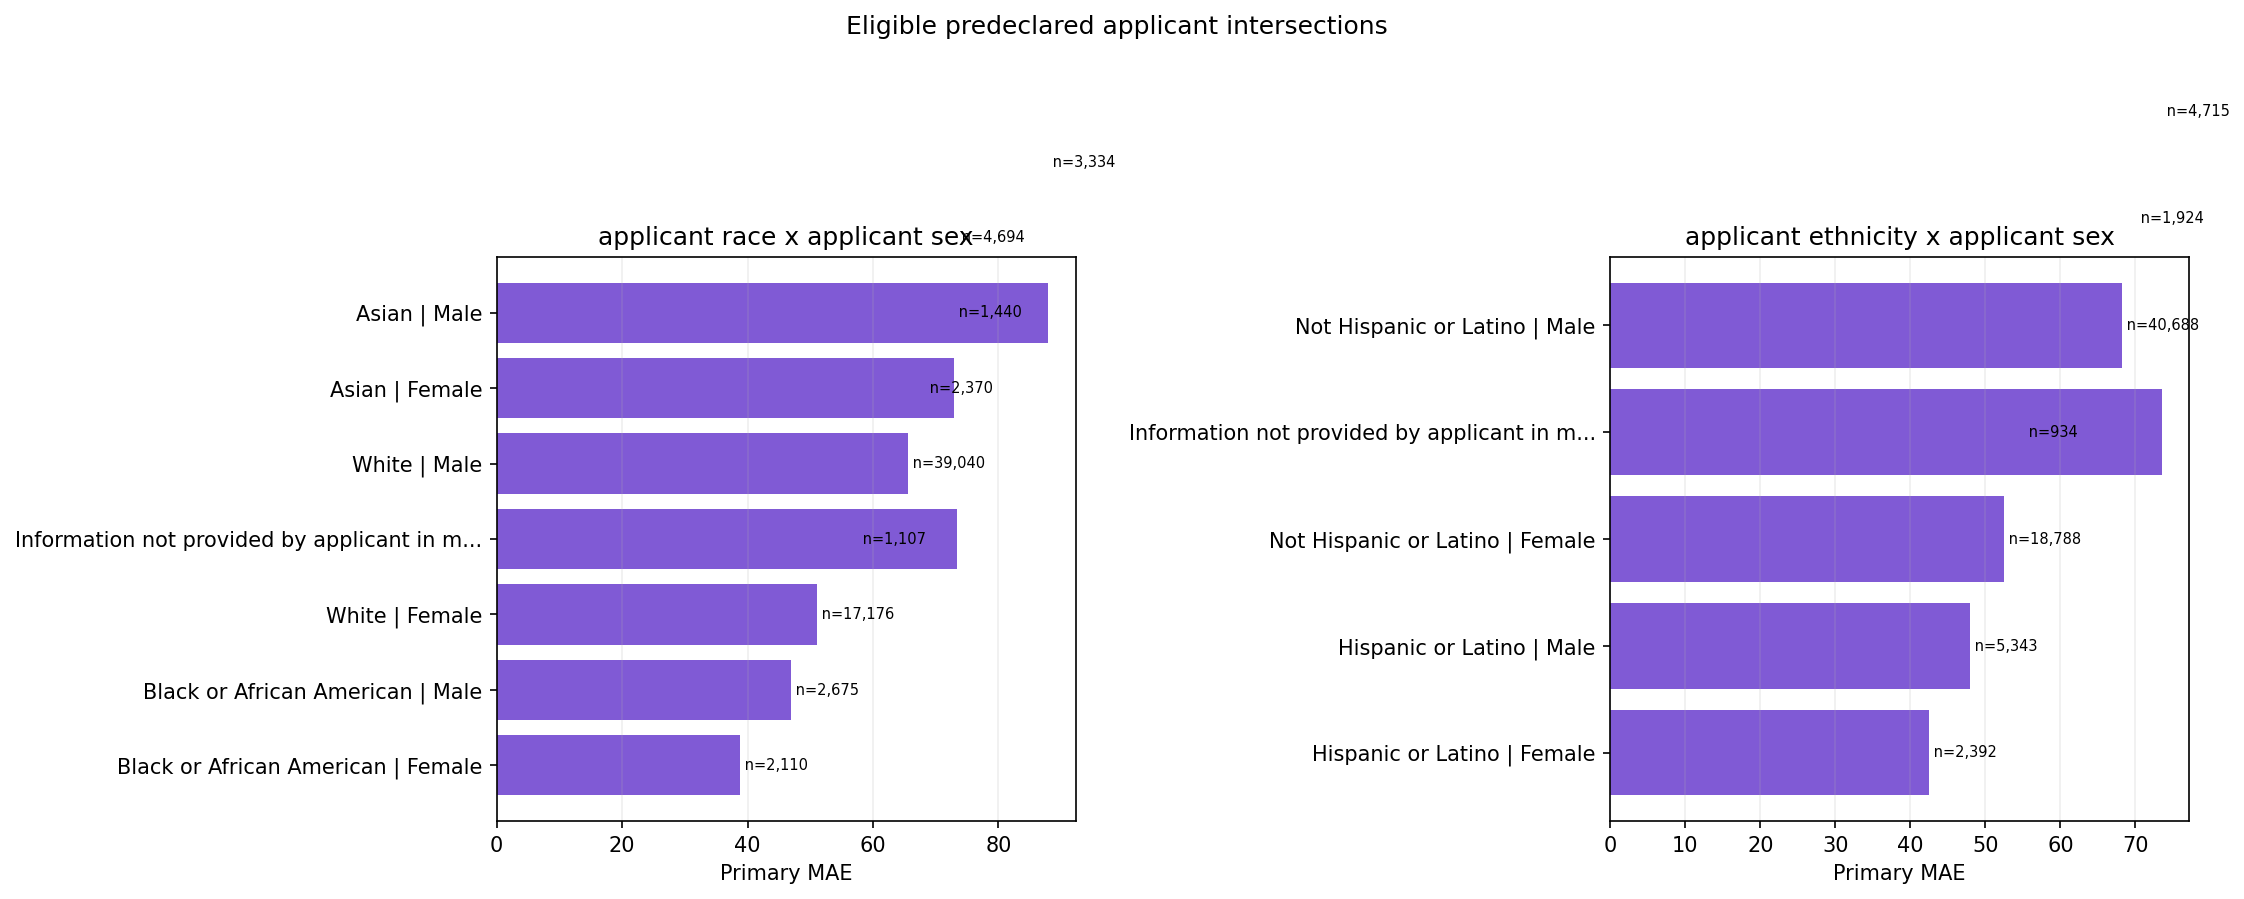

In [9]:
inter=pd.read_csv(R/'prompt5b_intersectional_metrics.csv')
display(inter[inter.analysis_status.eq('ELIGIBLE')])
display(Image(filename=str(F/'06_intersectional_mae.png')))

## 9. Hierarchical explanation

The final system is composite. Global prediction, Meta-Gate routing, Residual Specialist correction, and realized correction behavior are explained separately. No single SHAP decomposition is claimed for the full Stage 3 system.

In [10]:
display(pd.read_csv(R/'prompt5b_global_component_summary.csv'))

,component,frozen_weight,mean_component_prediction,mean_weighted_prediction_contribution,explanation_space,maximum_native_additivity_error,note
0,catboost,0.6,240.504991,144.302995,raw loan amount (thousand USD),4.320100e-12,Weighted model prediction contribution; not a ...
1,lightgbm,0.2,240.737469,48.147494,raw loan amount (thousand USD),1.159606e-11,Weighted model prediction contribution; not a ...
2,xgboost,0.2,234.088959,46.817792,native log1p target space,2.533767e-05,Weighted model prediction contribution; not a ...


## 10. Global prediction drivers

The consensus combines normalized feature ranks with frozen 0.60/0.20/0.20 model weights. Raw SHAP magnitudes are not added across models.

,feature,catboost_mean_abs_shap,catboost_rank,catboost_normalized_rank_score,catboost_space,lightgbm_mean_abs_shap,lightgbm_rank,lightgbm_normalized_rank_score,lightgbm_space,xgboost_mean_abs_shap,xgboost_rank,xgboost_normalized_rank_score,xgboost_space,consensus_rank_score,components_top5,components_top10,rank_transform,raw_shap_values_summed_across_models,consensus_rank
0,applicant_income_000s,25.678638,2,0.970588,raw loan amount (thousand USD),63.401191,1,1.000000,raw loan amount (thousand USD),0.267505,1,1.000000,native log1p target space,0.982353,3,3,"(35-rank)/(35-1); top rank=1, bottom rank=0",False,1
1,lien_status_name,18.699700,4,0.911765,raw loan amount (thousand USD),20.192802,5,0.882353,raw loan amount (thousand USD),0.230059,2,0.970588,native log1p target space,0.917647,3,3,"(35-rank)/(35-1); top rank=1, bottom rank=0",False,2
2,loan_purpose_name,15.603564,5,0.882353,raw loan amount (thousand USD),19.714257,6,0.852941,raw loan amount (thousand USD),0.079456,6,0.852941,native log1p target space,0.870588,1,3,"(35-rank)/(35-1); top rank=1, bottom rank=0",False,3
3,msamd_name,25.629440,3,0.941176,raw loan amount (thousand USD),9.472075,9,0.764706,raw loan amount (thousand USD),0.037236,10,0.735294,native log1p target space,0.864706,1,3,"(35-rank)/(35-1); top rank=1, bottom rank=0",False,4
4,owner_occupancy_name,11.030987,6,0.852941,raw loan amount (thousand USD),13.611795,7,0.823529,raw loan amount (thousand USD),0.053335,8,0.794118,native log1p target space,0.835294,0,3,"(35-rank)/(35-1); top rank=1, bottom rank=0",False,5
5,tract_to_msamd_income,6.710243,11,0.705882,raw loan amount (thousand USD),26.653925,3,0.941176,raw loan amount (thousand USD),0.101756,4,0.911765,native log1p target space,0.794118,2,2,"(35-rank)/(35-1); top rank=1, bottom rank=0",False,6
6,loan_type_name,6.866924,10,0.735294,raw loan amount (thousand USD),6.938035,10,0.735294,raw loan amount (thousand USD),0.039702,9,0.764706,native log1p target space,0.741176,0,3,"(35-rank)/(35-1); top rank=1, bottom rank=0",False,7
7,hud_median_family_income,3.414475,15,0.588235,raw loan amount (thousand USD),27.153491,2,0.970588,raw loan amount (thousand USD),0.104797,3,0.941176,native log1p target space,0.735294,2,2,"(35-rank)/(35-1); top rank=1, bottom rank=0",False,8
8,us_region,3.970698,14,0.617647,raw loan amount (thousand USD),23.144030,4,0.911765,raw loan amount (thousand USD),0.098281,5,0.882353,native log1p target space,0.729412,2,2,"(35-rank)/(35-1); top rank=1, bottom rank=0",False,9
9,county_name,8.699005,8,0.794118,raw loan amount (thousand USD),2.212916,20,0.441176,raw loan amount (thousand USD),0.013260,13,0.647059,native log1p target space,0.694118,0,1,"(35-rank)/(35-1); top rank=1, bottom rank=0",False,10


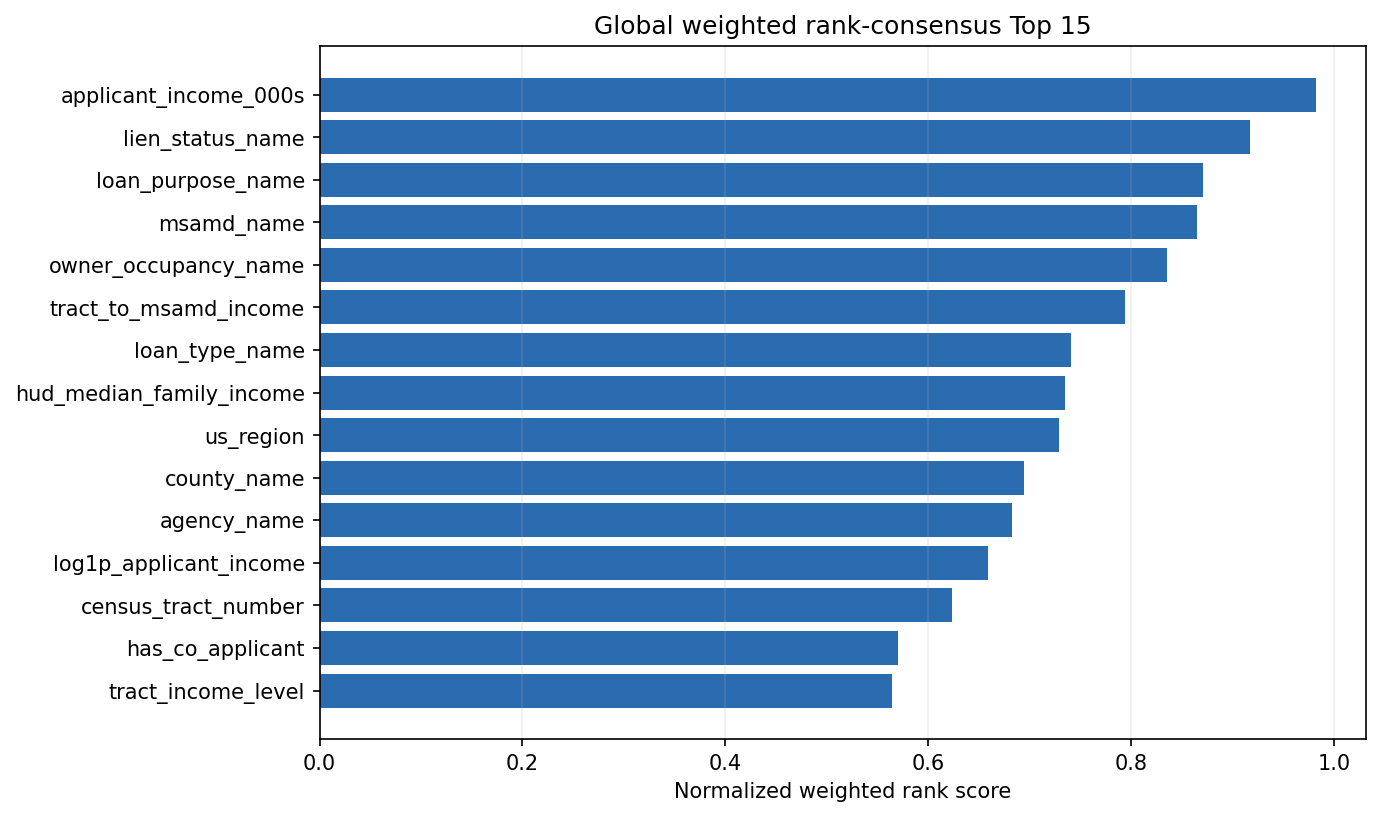

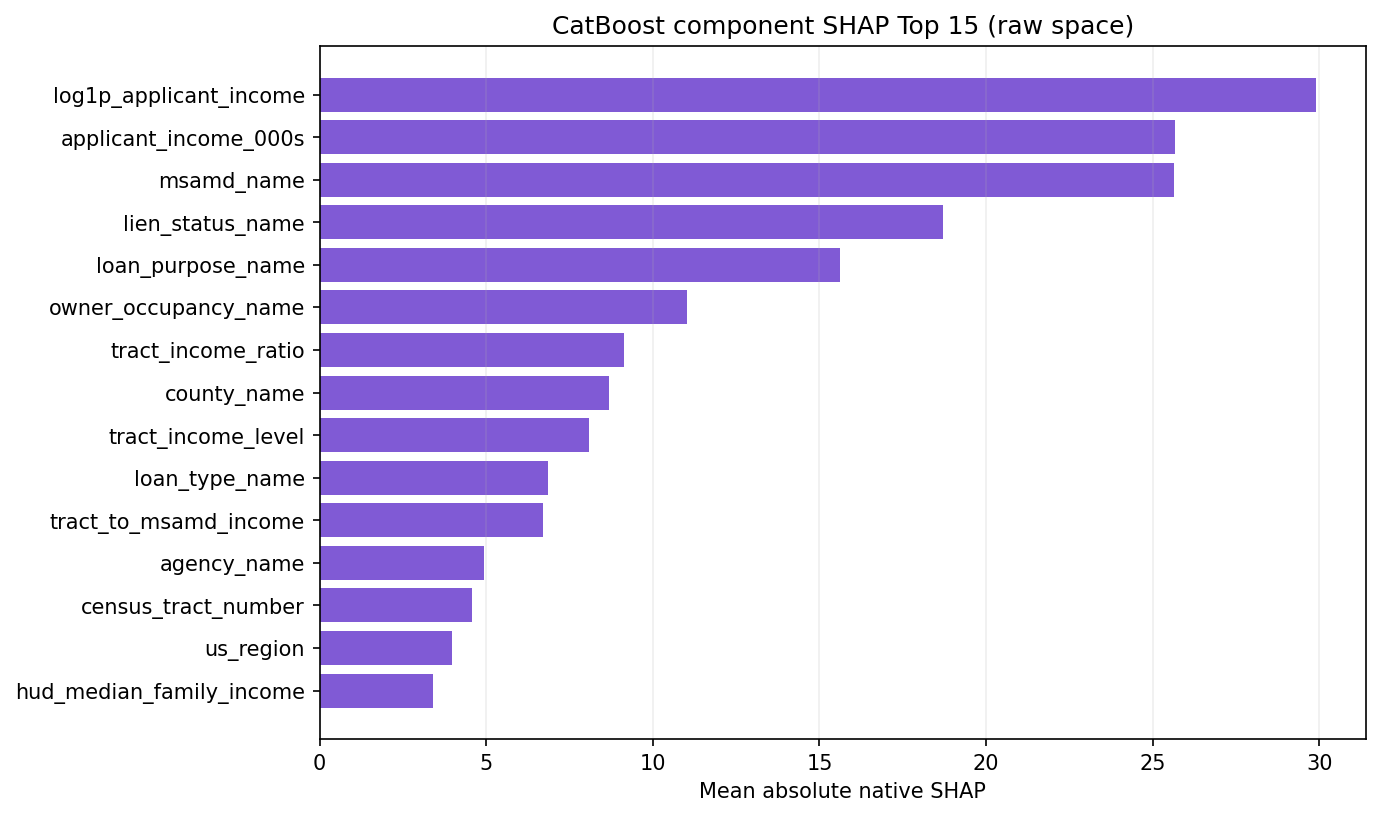

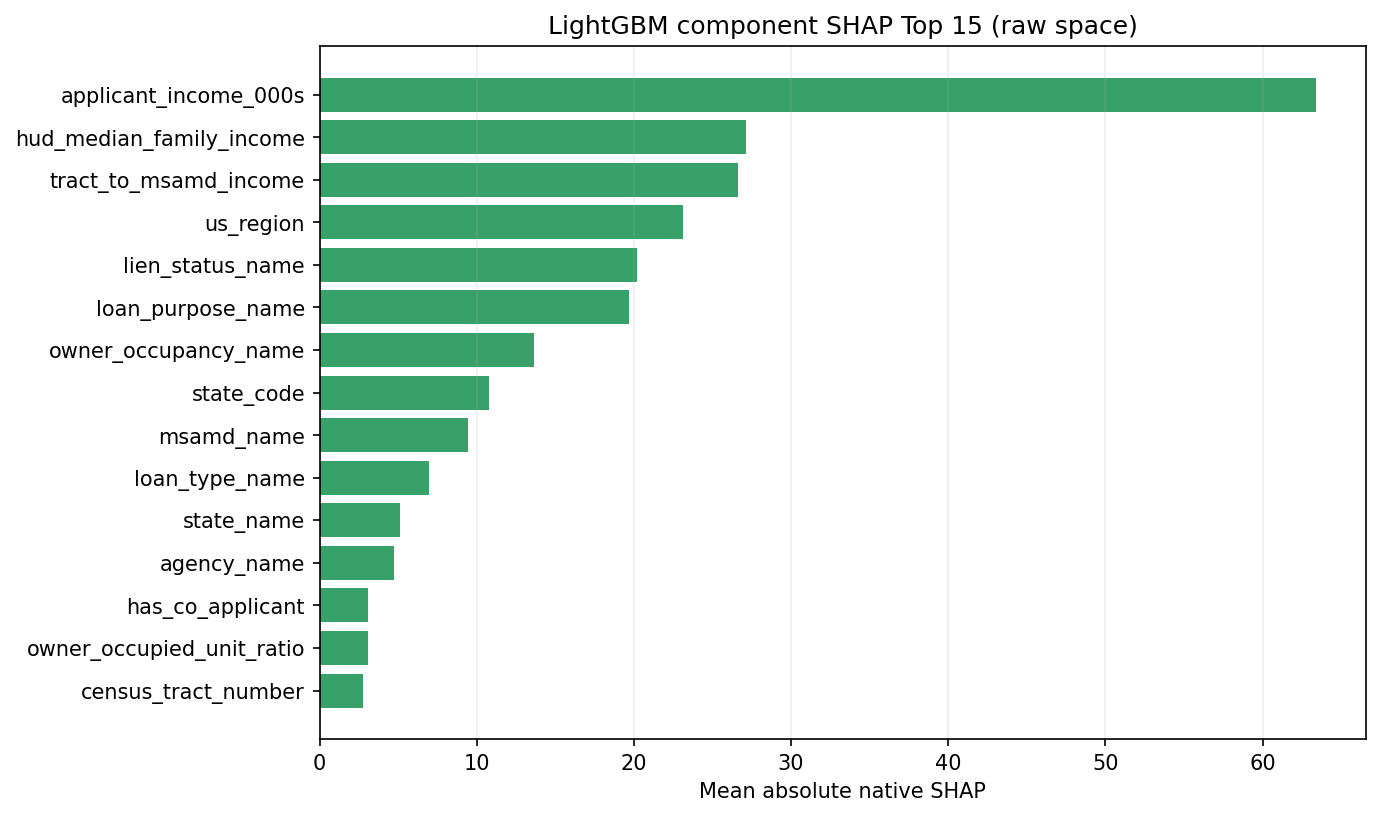

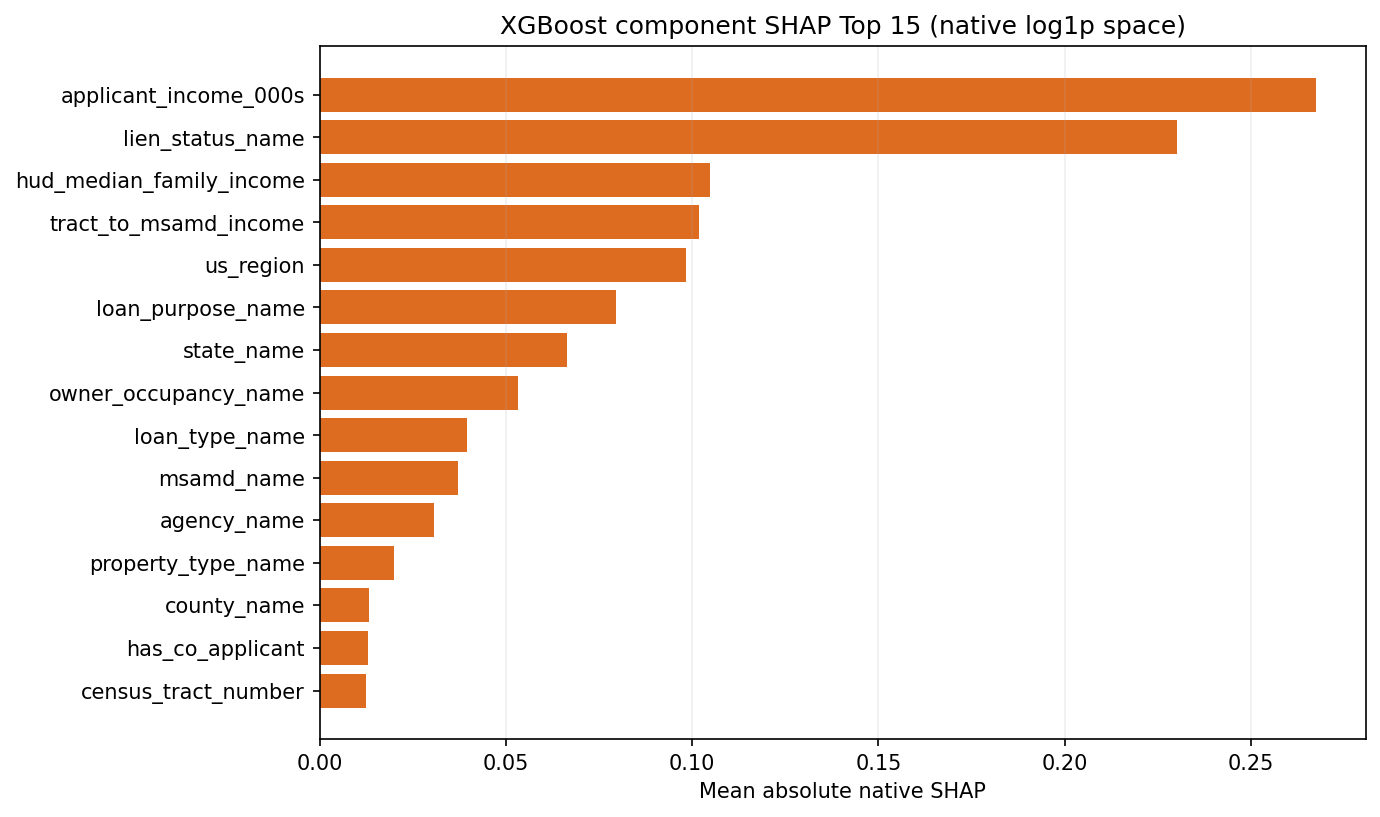

In [11]:
glob=pd.read_csv(R/'prompt5b_global_feature_importance.csv')
display(glob.head(15))
display(Image(filename=str(F/'07_global_consensus_top15.png')))
for name in ['08_catboost_shap_top15.png','09_lightgbm_shap_top15.png','10_xgboost_shap_top15.png']:
    display(Image(filename=str(F/name)))

## 11. XGBoost explanation scale

XGBoost uses historical log1p target semantics. Its SHAP values are in native log1p space and are not directly scale-comparable with raw-space CatBoost and LightGBM values.

## 12. Meta-Gate routing drivers

Gate importance asks which observed features push the frozen model toward Tail correction. It is not loan-amount importance. Global prediction is a model-derived Gate input, not an original dataset feature.

,importance_type,feature,mean_abs_shap,mean_signed_shap,rank,explanation_space,interpretation
0,Gate importance,global_prediction_feature,1.285039,0.040388,1,native CatBoost log-odds routing space,Features associated with routing toward Tail c...
1,Gate importance,log1p_applicant_income,0.338223,-0.016918,2,native CatBoost log-odds routing space,Features associated with routing toward Tail c...
2,Gate importance,applicant_income_000s,0.291330,0.003581,3,native CatBoost log-odds routing space,Features associated with routing toward Tail c...
3,Gate importance,agency_name,0.290628,-0.019747,4,native CatBoost log-odds routing space,Features associated with routing toward Tail c...
4,Gate importance,county_name,0.216748,-0.057961,5,native CatBoost log-odds routing space,Features associated with routing toward Tail c...
5,Gate importance,msamd_name,0.211249,-0.016285,6,native CatBoost log-odds routing space,Features associated with routing toward Tail c...
6,Gate importance,census_tract_number,0.194001,-0.035963,7,native CatBoost log-odds routing space,Features associated with routing toward Tail c...
7,Gate importance,loan_type_name,0.190311,-0.016262,8,native CatBoost log-odds routing space,Features associated with routing toward Tail c...
8,Gate importance,applicant_income_area_group,0.162736,0.003221,9,native CatBoost log-odds routing space,Features associated with routing toward Tail c...
9,Gate importance,loan_purpose_name,0.134431,-0.004905,10,native CatBoost log-odds routing space,Features associated with routing toward Tail c...


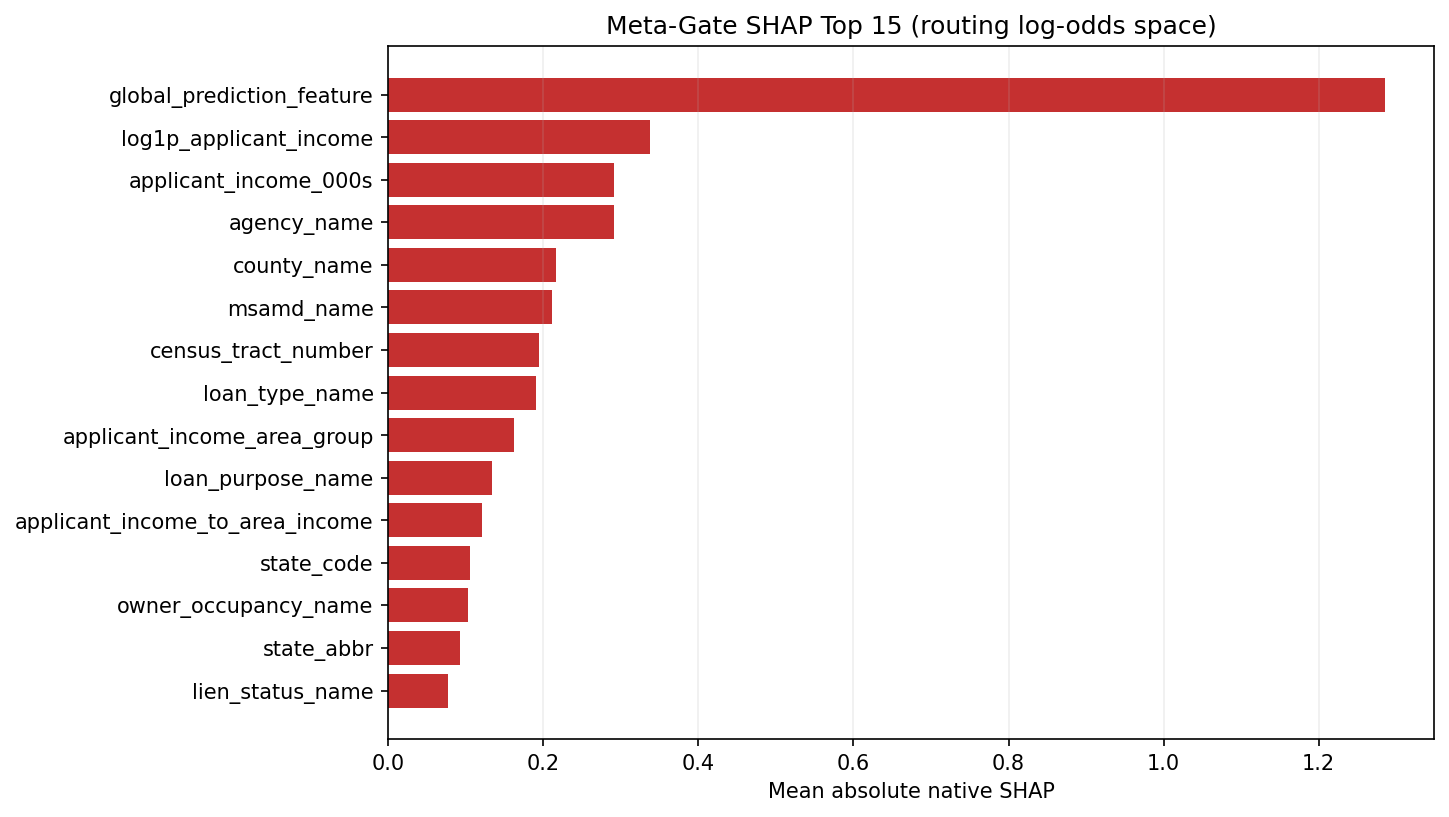

In [12]:
display(pd.read_csv(R/'prompt5b_gate_feature_importance.csv').head(15))
display(Image(filename=str(F/'11_gate_shap_top15.png')))

## 13. Residual Specialist correction drivers

Positive Specialist output means upward correction. Negative output means downward correction. This is not a direct loan-amount explanation.

,importance_type,feature,mean_abs_shap,mean_signed_shap,rank,explanation_space,interpretation
0,Residual correction importance,global_prediction_feature,128.322918,125.213670,1,raw residual-correction space (thousand USD),Positive output is upward correction; negative...
1,Residual correction importance,applicant_income_to_area_income,16.587013,-14.117778,2,raw residual-correction space (thousand USD),Positive output is upward correction; negative...
2,Residual correction importance,loan_purpose_name,11.007367,6.862766,3,raw residual-correction space (thousand USD),Positive output is upward correction; negative...
3,Residual correction importance,agency_name,10.781762,9.897098,4,raw residual-correction space (thousand USD),Positive output is upward correction; negative...
4,Residual correction importance,msamd_name,9.716316,7.267833,5,raw residual-correction space (thousand USD),Positive output is upward correction; negative...
5,Residual correction importance,owner_occupancy_name,7.279683,-1.774386,6,raw residual-correction space (thousand USD),Positive output is upward correction; negative...
6,Residual correction importance,loan_type_name,7.055823,5.378508,7,raw residual-correction space (thousand USD),Positive output is upward correction; negative...
7,Residual correction importance,log1p_applicant_income,5.045885,-4.180572,8,raw residual-correction space (thousand USD),Positive output is upward correction; negative...
8,Residual correction importance,state_abbr,4.900693,3.945665,9,raw residual-correction space (thousand USD),Positive output is upward correction; negative...
9,Residual correction importance,census_tract_number,4.615302,-0.734074,10,raw residual-correction space (thousand USD),Positive output is upward correction; negative...


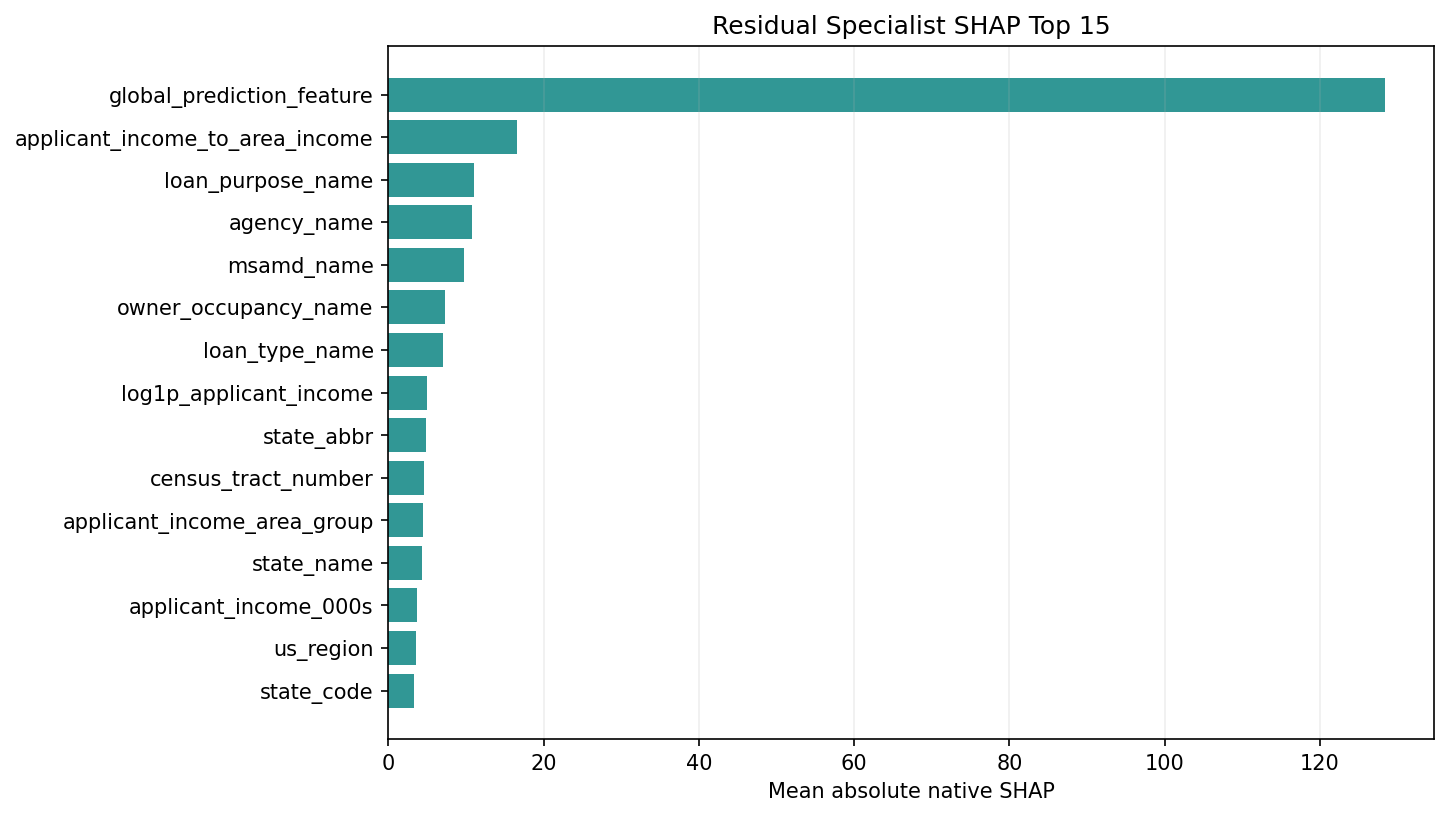

In [13]:
display(pd.read_csv(R/'prompt5b_residual_feature_importance.csv').head(15))
display(Image(filename=str(F/'12_residual_shap_top15.png')))

## 14. Body versus D10 importance

,component,feature,body_d1_d9_mean_abs_shap,d10_mean_abs_shap,d10_to_body_ratio,body_n,d10_n,explanation_space
0,catboost,agency_name,3.220536,20.132145,6.251178,3593,407,raw loan amount (thousand USD)
46,lightgbm,applicant_income_to_area_income,1.951295,9.164511,4.696631,3593,407,raw loan amount (thousand USD)
56,lightgbm,agency_name,3.563473,15.381761,4.316508,3593,407,raw loan amount (thousand USD)
22,catboost,log1p_hud_median_family_income,1.788247,7.568654,4.232442,3593,407,raw loan amount (thousand USD)
16,catboost,hud_median_family_income,2.711812,9.617590,3.546555,3593,407,raw loan amount (thousand USD)
9,catboost,state_code,2.486251,8.778949,3.530998,3593,407,raw loan amount (thousand USD)
17,catboost,tract_to_msamd_income,5.420072,18.099884,3.339418,3593,407,raw loan amount (thousand USD)
27,catboost,owner_occupied_unit_ratio,1.954447,6.339244,3.243498,3593,407,raw loan amount (thousand USD)
48,lightgbm,owner_occupied_unit_ratio,2.525310,8.078640,3.199068,3593,407,raw loan amount (thousand USD)
39,lightgbm,number_of_owner_occupied_units,1.150158,3.525975,3.065644,3593,407,raw loan amount (thousand USD)


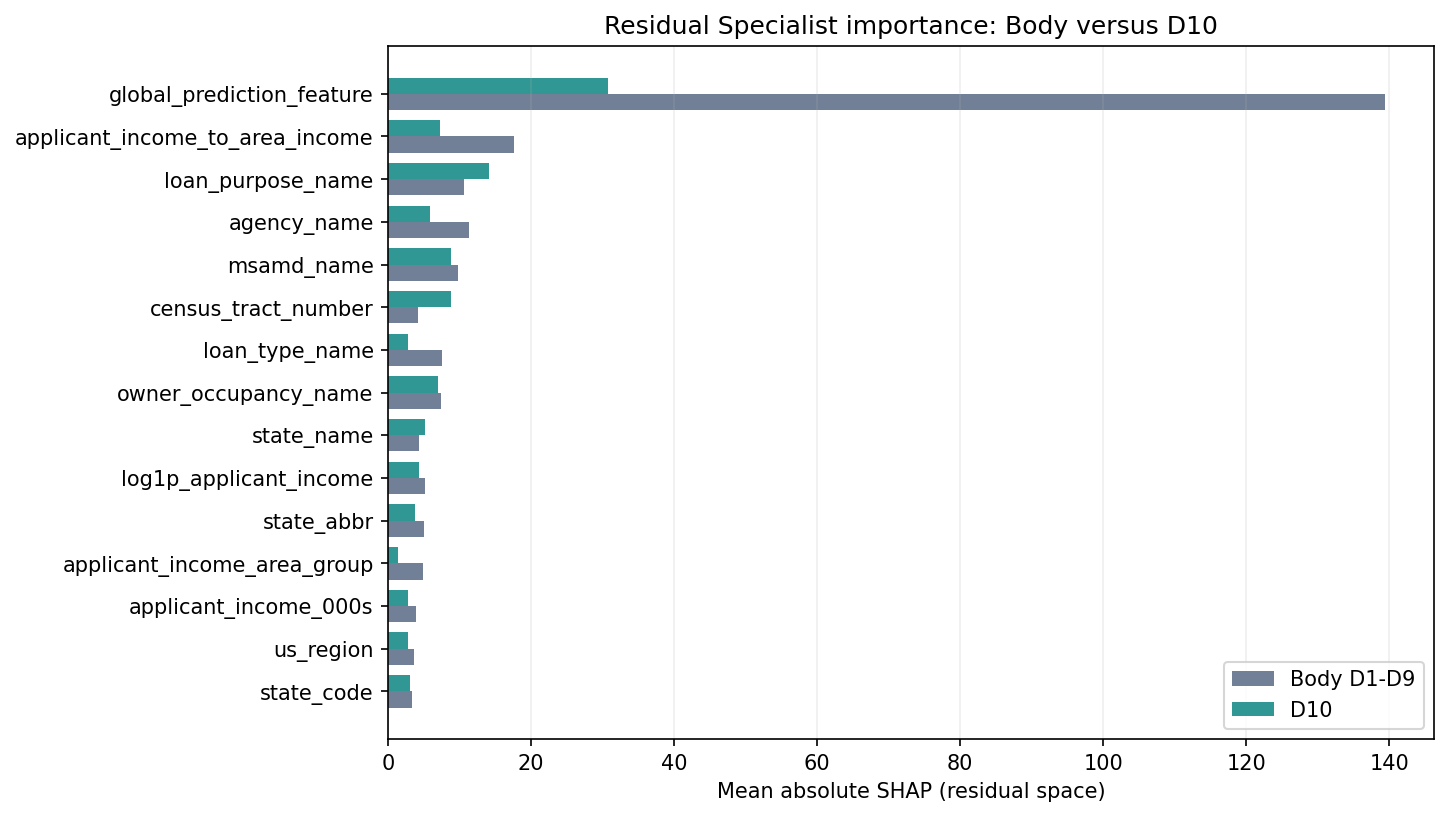

In [14]:
dexp=pd.read_csv(R/'prompt5b_decile_explainability.csv')
display(dexp.sort_values('d10_to_body_ratio',ascending=False).groupby('component').head(10))
display(Image(filename=str(F/'13_residual_body_vs_d10.png')))

## 15. Large-error explanation

This comparison is descriptive. It shows feature regimes associated with large errors; it is not causal.

In [15]:
err=pd.read_csv(R/'prompt5b_error_explainability.csv')
display(err.sort_values('top5_to_all_ratio',ascending=False).groupby('component').head(10))

,component,feature,all_sample_mean_abs_shap,top5_primary_error_mean_abs_shap,top5_to_all_ratio,all_n,top5_error_n,explanation_space
0,catboost,agency_name,4.941293,26.748529,5.413266,4000,203,raw loan amount (thousand USD)
46,lightgbm,applicant_income_to_area_income,2.685240,13.969118,5.202187,4000,203,raw loan amount (thousand USD)
56,lightgbm,agency_name,4.765984,20.000480,4.196506,4000,203,raw loan amount (thousand USD)
28,catboost,family_units_per_1000_people,2.032076,7.134242,3.510815,4000,203,raw loan amount (thousand USD)
36,lightgbm,population,0.737225,2.552107,3.461776,4000,203,raw loan amount (thousand USD)
14,catboost,applicant_income_000s,25.678638,82.507212,3.213068,4000,203,raw loan amount (thousand USD)
48,lightgbm,owner_occupied_unit_ratio,3.090362,9.782044,3.165340,4000,203,raw loan amount (thousand USD)
17,catboost,tract_to_msamd_income,6.710243,21.028235,3.133752,4000,203,raw loan amount (thousand USD)
35,lightgbm,applicant_income_000s,63.401191,193.688660,3.054969,4000,203,raw loan amount (thousand USD)
22,catboost,log1p_hud_median_family_income,2.376404,7.222391,3.039210,4000,203,raw loan amount (thousand USD)


## 16. Routing and correction mechanism

,section,scope,metric,value,n
0,direction,overall,positive_fraction,0.043693,75000
1,direction,overall,negative_fraction,0.004080,75000
2,direction,overall,zero_fraction,0.952227,75000
3,magnitude_quantile,overall,p0,0.000000,75000
4,magnitude_quantile,overall,p25,0.000000,75000
5,magnitude_quantile,overall,p50,0.000000,75000
6,magnitude_quantile,overall,p75,0.000000,75000
7,magnitude_quantile,overall,p90,0.000000,75000
8,magnitude_quantile,overall,p95,0.000000,75000
9,magnitude_quantile,overall,p99,39.388432,75000


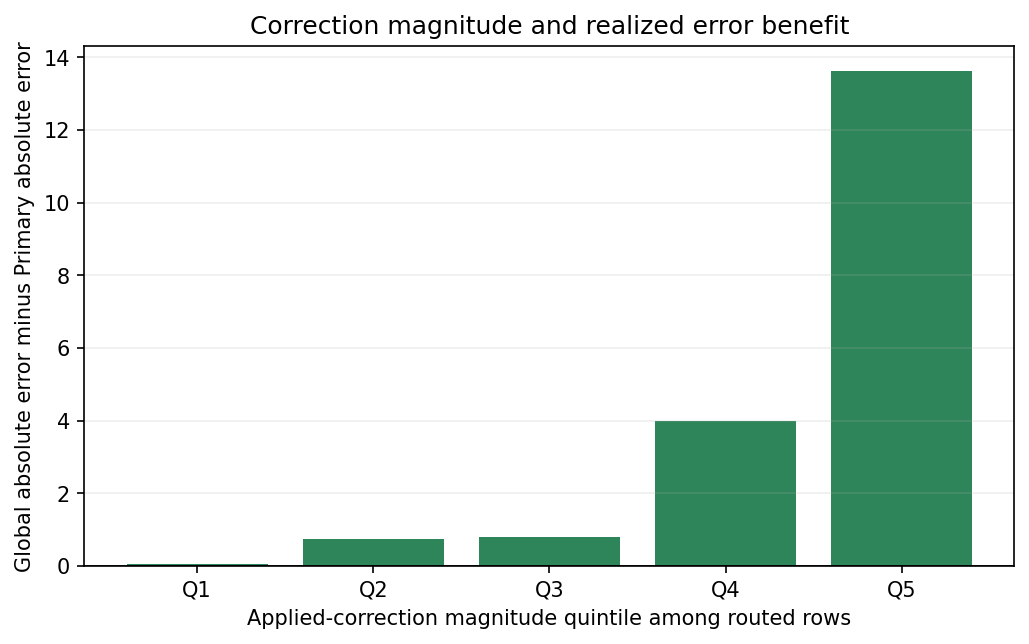

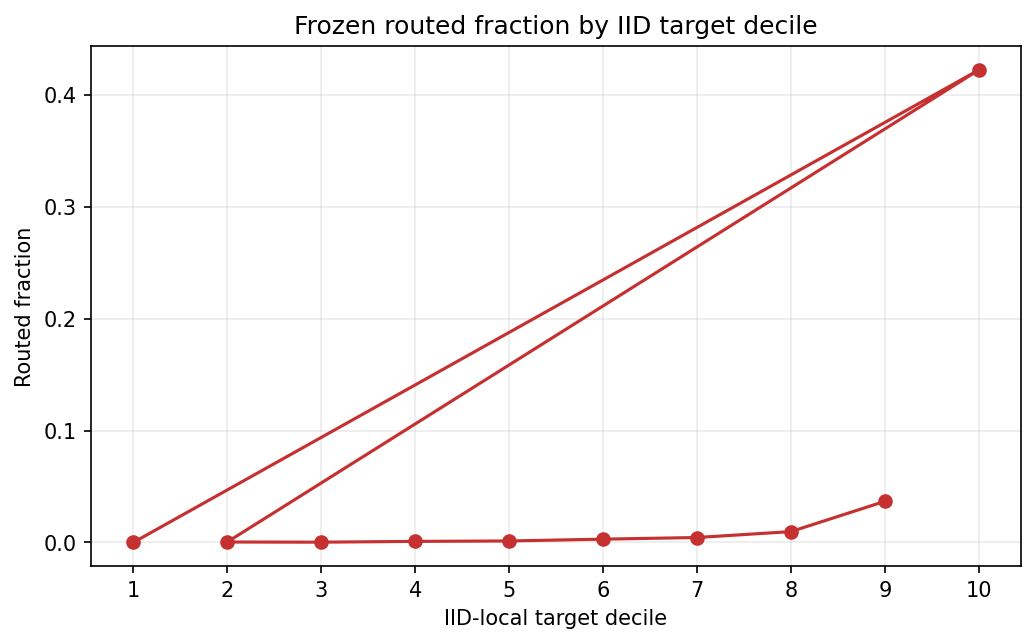

In [16]:
display(pd.read_csv(R/'prompt5b_correction_behavior.csv'))
display(Image(filename=str(F/'14_correction_magnitude_realized_benefit.png')))
display(Image(filename=str(F/'15_routed_fraction_by_decile.png')))

## 17. Sensitive-group routing cross-check

This is a post-hoc mechanism audit. Routing-rate parity is not asserted as a fairness requirement.

In [17]:
display(pd.read_csv(R/'prompt5b_routing_sensitive_audit.csv'))
display(pd.read_csv(R/'prompt5b_fairness_explainability_link.csv'))

,sensitive_field,group_label,n,mean_target,median_target,d10_fraction,top5_target_fraction,routing_rate,mean_applied_correction,primary_minus_global_mae_routed,routed_n,primary_minus_global_mae_non_routed,non_routed_n,interpretation
0,applicant_ethnicity_name,Hispanic or Latino,7760,218.900000,192.0,0.062500,0.021778,0.022552,0.405948,-3.878306,175,0.0,7585,Descriptive mechanism audit; routing-rate pari...
1,applicant_ethnicity_name,"Information not provided by applicant in mail,...",7574,275.267890,217.0,0.130182,0.068788,0.068524,2.332958,-10.314064,519,0.0,7055,Descriptive mechanism audit; routing-rate pari...
2,applicant_ethnicity_name,Not Hispanic or Latino,59613,250.232063,202.0,0.100733,0.051801,0.048362,1.314806,-2.699685,2883,0.0,56730,Descriptive mechanism audit; routing-rate pari...
3,co_applicant_ethnicity_name,Hispanic or Latino,3239,250.523927,220.0,0.091386,0.036431,0.038283,0.624036,-3.572480,124,0.0,3115,Descriptive mechanism audit; routing-rate pari...
4,co_applicant_ethnicity_name,"Information not provided by applicant in mail,...",3893,301.196763,240.0,0.159774,0.082969,0.086052,2.786980,-7.928990,335,0.0,3558,Descriptive mechanism audit; routing-rate pari...
5,co_applicant_ethnicity_name,No co-applicant,40692,222.414824,180.0,0.072742,0.036002,0.033102,0.996367,-3.646978,1347,0.0,39345,Descriptive mechanism audit; routing-rate pari...
6,co_applicant_ethnicity_name,Not Hispanic or Latino,27118,282.799985,230.5,0.132679,0.069142,0.065492,1.699013,-3.234049,1776,0.0,25342,Descriptive mechanism audit; routing-rate pari...
7,applicant_race_name_1,American Indian or Alaska Native,507,207.958580,179.0,0.076923,0.027613,0.023669,0.467284,-9.864566,12,0.0,495,Descriptive mechanism audit; routing-rate pari...
8,applicant_race_name_1,Asian,4792,358.291319,300.0,0.246661,0.130843,0.142529,2.942411,-2.460767,683,0.0,4109,Descriptive mechanism audit; routing-rate pari...
9,applicant_race_name_1,Black or African American,4800,201.034375,176.0,0.046458,0.018958,0.017500,0.384157,-6.126022,84,0.0,4716,Descriptive mechanism audit; routing-rate pari...


,sensitive_field,group_label,n,mean_target,median_target,d10_fraction,top5_target_fraction,elevated_mae_descriptive,elevated_underprediction_descriptive,primary_top5_abs_error_fraction,high_correction_magnitude_fraction,routed_fraction,interpretation
0,applicant_ethnicity_name,Hispanic or Latino,7760,218.900000,192.0,0.062500,0.021778,False,False,0.023840,1.0,0.022552,Descriptive link only; explanations do not exp...
1,applicant_ethnicity_name,"Information not provided by applicant in mail,...",7574,275.267890,217.0,0.130182,0.068788,True,False,0.063507,1.0,0.068524,Descriptive link only; explanations do not exp...
2,applicant_ethnicity_name,Not Hispanic or Latino,59613,250.232063,202.0,0.100733,0.051801,True,False,0.051633,1.0,0.048362,Descriptive link only; explanations do not exp...
3,co_applicant_ethnicity_name,Hispanic or Latino,3239,250.523927,220.0,0.091386,0.036431,False,False,0.035196,1.0,0.038283,Descriptive link only; explanations do not exp...
4,co_applicant_ethnicity_name,"Information not provided by applicant in mail,...",3893,301.196763,240.0,0.159774,0.082969,True,False,0.072181,1.0,0.086052,Descriptive link only; explanations do not exp...
5,co_applicant_ethnicity_name,No co-applicant,40692,222.414824,180.0,0.072742,0.036002,False,False,0.037206,1.0,0.033102,Descriptive link only; explanations do not exp...
6,co_applicant_ethnicity_name,Not Hispanic or Latino,27118,282.799985,230.5,0.132679,0.069142,True,False,0.067852,1.0,0.065492,Descriptive link only; explanations do not exp...
7,applicant_race_name_1,American Indian or Alaska Native,507,207.958580,179.0,0.076923,0.027613,False,False,0.021696,1.0,0.023669,Descriptive link only; explanations do not exp...
8,applicant_race_name_1,Asian,4792,358.291319,300.0,0.246661,0.130843,True,True,0.091820,1.0,0.142529,Descriptive link only; explanations do not exp...
9,applicant_race_name_1,Black or African American,4800,201.034375,176.0,0.046458,0.018958,False,False,0.018750,1.0,0.017500,Descriptive link only; explanations do not exp...


## 18. SHAP stability

In [18]:
display(pd.read_csv(R/'prompt5b_explainability_stability.csv'))

,component,half_0_n,half_1_n,top10_overlap_count,top10_overlap_fraction,spearman_rank_correlation,explanation_space
0,catboost,1968,2032,10,1.0,0.998319,raw loan amount (thousand USD)
1,lightgbm,1968,2032,10,1.0,0.998593,raw loan amount (thousand USD)
2,xgboost,1968,2032,10,1.0,1.000000,native log1p target space
3,gate,1968,2032,10,1.0,0.998713,native CatBoost log-odds routing space
4,residual,1968,2032,10,1.0,0.998198,raw residual-correction space (thousand USD)


## 19. Six deterministic local cases

Cases follow frozen rules. IDs are pseudonymous, sensitive values are not shown, and explanations are not causal.

In [19]:
display(pd.read_csv(R/'prompt5b_local_cases.csv'))
local_contrib=pd.read_parquet(ROOT/'outputs/explainability/prompt5b/local_case_contributions.parquet')
display(local_contrib[local_contrib['rank']<=5].sort_values(['case_role','component','rank']))

## 20. Limitations and closure

Sensitive variables were excluded from Primary inputs and used only after prediction for audit. Observational group differences are not causal effects. Group target distributions differ. This is not a lending approval model. The audit does not prove absence or presence of discrimination. Small-group estimates are unstable, and multiple comparisons are descriptive. No model, feature, threshold, weight, routing rule, or correction policy changed.